# 第二部分：机器学习基础

本章使用 **scikit-learn** 作为主要工具，覆盖经典机器学习算法的核心概念与实践。

## 目录

|  | 章节 | 内容 |
|--|------|------|
| **机器学习概述** | **2.1 机器学习概述** | 问题类型、学习范式、基本流程 |
| | **2.2 数据预处理** | 缺失值处理、特征缩放、编码 |
| **无监督学习** | **2.3 降维** | PCA 原理、SVD vs PCA |
| | **2.4 聚类算法** | K-Means、DBSCAN |
| **监督学习** | **2.5 线性模型** | 回归任务（线性回归、Ridge/Lasso、多项式）、分类任务（逻辑回归） |
| | **2.6 树模型** | 决策树、随机森林、梯度提升（XGBoost） |
| | **2.7 支持向量机** | 硬间隔、软间隔、核函数 |
| **评估** | **2.8 模型评估** | 交叉验证、偏差-方差权衡、分类/回归指标 |

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, make_classification, make_regression, make_blobs, make_moons
from sklearn.model_selection import train_test_split

matplotlib.rcParams['font.family'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
print('环境就绪')

环境就绪


---

# 第一部分：机器学习概述

---

## 2.1 机器学习概述

### 什么是机器学习

机器学习是让计算机**从数据中自动找规律**，而不是手动编写规则。

传统编程：`数据 + 规则 → 答案`  
机器学习：`数据 + 答案 → 规则（模型）`

### 三种学习范式

| 类型 | 有无标签 | 目标 | 典型算法 |
|------|----------|------|----------|
| **监督学习** | 有 | 预测输出 y | 线性回归、逻辑回归、随机森林 |
| **无监督学习** | 无 | 发现数据结构 | K-Means、PCA、自编码器 |
| **强化学习** | 奖励信号 | 学习最优策略 | Q-Learning、PPO |

### 监督学习的两类问题

- **回归（Regression）**：预测连续值（房价、股价、温度）
- **分类（Classification）**：预测离散类别（垃圾邮件/正常、猫/狗/鸟）

### 无监督学习的主要任务

没有标签，目标是从数据本身发现结构、模式或异常。

| 任务 | 目标 | 典型算法 | 本章对应 |
|------|------|----------|----------|
| **聚类（Clustering）** | 将相似样本分组 | K-Means、DBSCAN | 2.4 |
| **降维（Dimensionality Reduction）** | 用更少维度表示数据，保留主要结构 | PCA、t-SNE、UMAP | 2.3 |
| **异常检测（Anomaly Detection）** | 找出与大多数样本显著不同的点 | Isolation Forest、DBSCAN | 2.4（DBSCAN 噪声点） |
| **生成建模（Generative Modeling）** | 学习数据分布，生成新样本 | VAE、GAN、扩散模型 | 第三章 |

**聚类 vs 分类**：看起来都是"给样本打标签"，但有三处本质不同：

| | 分类 | 聚类 |
|--|------|------|
| **训练数据** | 有标签 | 无标签 |
| **类别由谁定义** | 人事先定义（"垃圾邮件"/"正常邮件"） | 算法从数据结构中自行发现 |
| **输出标签的含义** | 预定义，语义明确 | 任意编号（0/1/2…），语义需人事后解读 |
| **能否用于新样本** | 是（天然泛化） | 取决于算法：K-Means 可以，DBSCAN 不行 |

### 标准 ML 工作流

```
原始数据 → 数据预处理 → 特征工程 → 模型选择 → 训练 → 评估 → 调参 → 部署
```

## 2.2 数据预处理

真实数据往往有缺失值、量纲不一致、类别型特征等问题，直接喂给模型会影响效果。预处理是 ML 流程中最耗时也最重要的环节。

### 缺失值处理

- **删除**：缺失比例高的列/行
- **填充**：均值/中位数（数值）、众数/固定值（类别）
- **预测填充**：用其他特征训练模型来预测缺失值

### 特征缩放

许多算法（KNN、SVM、神经网络、线性回归+正则化）对特征量纲敏感，需要缩放。树模型不需要缩放。

| 方法 | 公式 | 特点 |
|------|------|------|
| **StandardScaler** | (x - μ) / σ | 均值0方差1，适合大多数场景 |
| **MinMaxScaler** | (x - min) / (max - min) | 压缩到 [0,1]，对异常值敏感 |
| **RobustScaler** | (x - 中位数) / IQR | 对异常值不敏感 |

=== 原始数据 ===
 年龄（岁）  月收入（元）  工作年限（年）
    25    8000        2
    32   25000        8
    45   15000       20
    28   12000        5
    52   45000       28

各特征的数值范围和标准差：
  年龄（岁）        范围     25 ~     52，标准差 =     11.6
  月收入（元）       范围   8000 ~  45000，标准差 =  14815.5
  工作年限（年）      范围      2 ~     28，标准差 =     11.0

⚠️  问题：月收入的数值是年龄的约 1000 倍、是工作年限的约 3000 倍
   对于 KNN、SVM 等基于距离的算法，样本间距离几乎完全由月收入决定
   年龄和工作年限的差异被完全淹没，相当于这两个特征没有参与计算


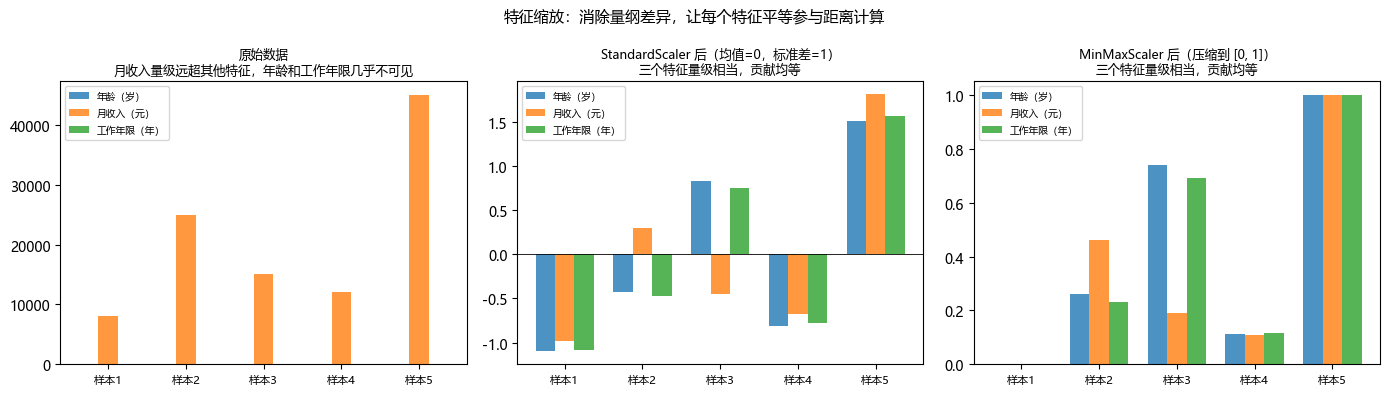


=== StandardScaler 后（均值=0，标准差=1）===
 年龄（岁）  月收入（元）  工作年限（年）
 -1.10   -0.98    -1.08
 -0.42    0.30    -0.47
  0.83   -0.45     0.75
 -0.81   -0.68    -0.77
  1.51    1.81     1.57

=== MinMaxScaler 后（范围 [0, 1]）===
 年龄（岁）  月收入（元）  工作年限（年）
  0.00    0.00     0.00
  0.26    0.46     0.23
  0.74    0.19     0.69
  0.11    0.11     0.12
  1.00    1.00     1.00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# ── 原始数据：三个特征量纲差异悬殊 ──────────────────────────
df = pd.DataFrame({
    '年龄（岁）':    [25, 32, 45, 28, 52],
    '月收入（元）':  [8000, 25000, 15000, 12000, 45000],
    '工作年限（年）': [2, 8, 20, 5, 28],
})

print("=== 原始数据 ===")
print(df.to_string(index=False))
print("\n各特征的数值范围和标准差：")
for col in df.columns:
    print(f"  {col:<12} 范围 {df[col].min():>6} ~ {df[col].max():>6}，标准差 = {df[col].std():>8.1f}")

print("\n⚠️  问题：月收入的数值是年龄的约 1000 倍、是工作年限的约 3000 倍")
print("   对于 KNN、SVM 等基于距离的算法，样本间距离几乎完全由月收入决定")
print("   年龄和工作年限的差异被完全淹没，相当于这两个特征没有参与计算")

# ── 缩放处理 ──────────────────────────────────────────────────
df_std    = pd.DataFrame(StandardScaler().fit_transform(df), columns=df.columns)
df_minmax = pd.DataFrame(MinMaxScaler().fit_transform(df),   columns=df.columns)

# ── 可视化：原始 vs 两种缩放结果 ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
x     = np.arange(len(df))
width = 0.25
colors = ['C0', 'C1', 'C2']

for ax, data, title in zip(axes,
    [df, df_std, df_minmax],
    ['原始数据\n月收入量级远超其他特征，年龄和工作年限几乎不可见',
     'StandardScaler 后（均值=0，标准差=1）\n三个特征量级相当，贡献均等',
     'MinMaxScaler 后（压缩到 [0, 1]）\n三个特征量级相当，贡献均等']):
    for i, (col, c) in enumerate(zip(data.columns, colors)):
        ax.bar(x + i * width, data[col], width, label=col, color=c, alpha=0.8)
    ax.set_xticks(x + width)
    ax.set_xticklabels([f'样本{i+1}' for i in range(len(df))], fontsize=8)
    ax.axhline(0, color='k', lw=0.6)
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle('特征缩放：消除量纲差异，让每个特征平等参与距离计算', fontsize=11)
plt.tight_layout()
plt.show()

print("\n=== StandardScaler 后（均值=0，标准差=1）===")
print(df_std.round(2).to_string(index=False))
print("\n=== MinMaxScaler 后（范围 [0, 1]）===")
print(df_minmax.round(2).to_string(index=False))

### 类别特征编码

类别特征（如城市、教育程度、商品类型）无法直接输入模型，需要转换为数值。

| 方法 | 适用场景 | 注意 |
|------|----------|------|
| **LabelEncoder** | 有序类别（低/中/高）、树模型的任意类别 | 不适合无序类别 + 线性模型：会误引入大小关系 |
| **OrdinalEncoder** | 多列有序类别，需手动指定顺序 | 与 LabelEncoder 类似，但支持多列且顺序可控 |
| **OneHotEncoder** | 无序类别 + 线性模型 / SVM / 神经网络 | 类别数量多时（几十上百个）会导致维度爆炸 |

**选择原则**：
- **树模型**（随机森林、XGBoost）：`LabelEncoder` 即可，树不受数值大小误导
- **线性模型 / SVM**：无序类别必须用 `OneHotEncoder`；有序类别用 `OrdinalEncoder` 并指定顺序
- **高基数类别**（如用户 ID、城市名，几百个取值）：`OneHotEncoder` 维度爆炸，需考虑 Target Encoding 或 Embedding

---

# 第二部分：无监督学习

---

## 2.3 降维

高维数据直接使用会带来「维度灾难」：计算量爆炸、样本稀疏、可视化困难。降维的目标是**用更少的维度保留最多的信息**。

### PCA（Principal Component Analysis，主成分分析）

PCA 是最经典的无监督降维方法，将高维数据投影到**方差最大**的方向上。

**核心思路**：
1. **中心化**：减去列均值，消除背景偏移（必须做）
2. 计算协方差矩阵，找出方差最大的方向（主成分）
3. 按解释方差比从大到小排列，取前 k 个方向投影

**典型用途**：
- 高维数据可视化（压缩到 2D/3D 画图）
- 消除冗余特征，减少计算量
- 去除噪声（低方差方向往往是噪声）

**主成分数量怎么选**？看**累计解释方差比**，通常选覆盖 80%~95% 方差所需的最少主成分数。

### SVD vs PCA

第一章的 SVD 与 PCA 密切相关：

| | 操作 | 适用场景 |
|--|------|---------|
| **原始 SVD** | 直接分解矩阵 A | 矩阵本身有意义（如词频矩阵） |
| **PCA** | 先中心化，再做 SVD | 统计降维（特征的方差有意义） |

`sklearn.PCA` 内部就是对**中心化后**的数据矩阵做 SVD，两者数学等价。特征量纲不同时（如身高+体重+年龄）才需要额外加 `StandardScaler` 再做 PCA。

下面用第一章的 20 篇文章 × 10 词汇数据，直观对比两者的差异。

每个词的平均词频（PCA 要先减去这部分背景值）：
  模型    均值 = 5.4
  训练    均值 = 5.5
  数据    均值 = 5.0
  神经网络  均值 = 5.0
  文本    均值 = 3.4
  图像    均值 = 3.6
  词向量   均值 = 3.0
  奖励    均值 = 3.2
  策略    均值 = 3.2
  分类    均值 = 5.2

sklearn PCA 与手动中心化 SVD 坐标对比（前 3 篇文章）：
  文章                        手动中心化 SVD            sklearn PCA
  监督学习入门               (-2.68, +0.54)         (-2.68, +0.54)
  决策树原理                (-2.80, +1.05)         (-2.80, +1.05)
  随机森林调参               (-1.18, +0.85)         (-1.18, +0.85)
  → 数值相同（轴方向可能镜像，但空间结构完全一致）


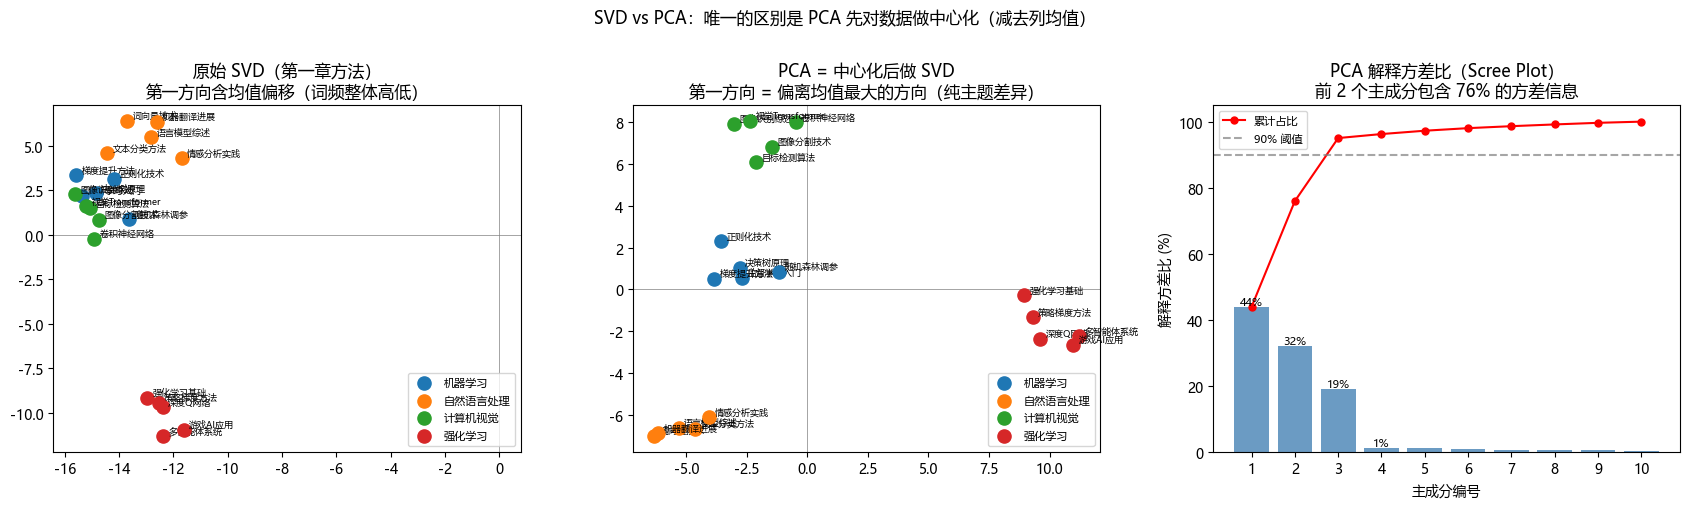


=== 为什么有了 SVD 还需要 PCA？ ===

  SVD（原始矩阵）:
    第一奇异方向由词频绝对量主导，含均值偏移（文章整体词频高低）
    适合：矩阵结构分解，如推荐系统的用户-商品矩阵

  PCA = 先减均值，再做 SVD:
    消除「背景词频」，只保留「偏差」：这篇文章比平均多用了哪些词？
    第一主成分 = 区分文章主题差异最显著的方向
    适合：数据分析、可视化、特征降维

  关系总结:
    np.linalg.svd(A)              → 纯数学工具，直接分解
    sklearn.PCA.fit_transform(A)  → 自动中心化 + SVD + 解释方差比

  何时还需要 StandardScaler（除以标准差）？
    特征量纲不同时：身高(cm)、体重(kg)、年龄(岁) 方差差异巨大
    需要 StandardScaler → PCA，否则方差大的特征会主导结果
    本例词频量纲一致（都是次数），只中心化即可，无需 StandardScaler


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ── 与第一章完全相同的文章词频数据 ───────────────────────────
words = ["模型","训练","数据","神经网络","文本","图像","词向量","奖励","策略","分类"]
articles = [
    "监督学习入门","决策树原理","随机森林调参","梯度提升方法","正则化技术",
    "词向量技术",  "语言模型综述","文本分类方法","机器翻译进展","情感分析实践",
    "图像识别综述","卷积神经网络","目标检测算法","图像分割技术","视觉Transformer",
    "强化学习基础","策略梯度方法","深度Q网络",  "多智能体系统","游戏AI应用",
]
topic_labels = ['机器学习']*5 + ['自然语言处理']*5 + ['计算机视觉']*5 + ['强化学习']*5
colors       = ['C0']*5 + ['C1']*5 + ['C2']*5 + ['C3']*5

base = np.array([
    [8, 6, 7, 2, 1, 1, 0, 0, 0, 5],
    [4, 3, 3, 2, 8, 1, 7, 0, 0, 6],
    [3, 5, 4, 7, 1, 9, 0, 0, 0, 4],
    [2, 4, 2, 5, 0, 0, 0, 8, 9, 2],
], dtype=float)
np.random.seed(42)
A = np.vstack([base[i // 5] + np.random.randint(0, 3, size=10) for i in range(20)])

# ── 核心区别：PCA 先对数据做中心化 ───────────────────────────
col_mean   = A.mean(axis=0)    # 每个词在所有文章的平均词频 (10,)
A_centered = A - col_mean      # 减均值后：体现"比平均多/少用了哪些词"

print("每个词的平均词频（PCA 要先减去这部分背景值）：")
for w, m in zip(words, col_mean):
    print(f"  {w:<5} 均值 = {m:.1f}")

# ── 方法一：SVD 直接作用于原始矩阵（第一章做法）────────────
_, _, Vt_raw = np.linalg.svd(A, full_matrices=False)
coords_raw   = A @ Vt_raw[:2].T            # shape: (20, 2)

# ── 方法二：手动中心化后做 SVD（= PCA 的数学本质）───────────
_, _, Vt_cen = np.linalg.svd(A_centered, full_matrices=False)
coords_cen   = A_centered @ Vt_cen[:2].T  # shape: (20, 2)

# ── 方法三：sklearn PCA（内部自动中心化 + SVD）───────────────
pca2        = PCA(n_components=2)
coords_pca  = pca2.fit_transform(A)        # 与方法二数学等价（方向可能镜像）

# ── 验证等价性 ────────────────────────────────────────────────
print(f"\nsklearn PCA 与手动中心化 SVD 坐标对比（前 3 篇文章）：")
print(f"  {'文章':<12} {'手动中心化 SVD':>22} {'sklearn PCA':>22}")
for i in range(3):
    a = f"({coords_cen[i,0]:+.2f}, {coords_cen[i,1]:+.2f})"
    b = f"({coords_pca[i,0]:+.2f}, {coords_pca[i,1]:+.2f})"
    print(f"  {articles[i]:<12} {a:>22} {b:>22}")
print("  → 数值相同（轴方向可能镜像，但空间结构完全一致）")

# ── 可视化：三图对比 ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

def scatter_articles(ax, coords, title, xlabel='', ylabel=''):
    seen = set()
    for i in range(20):
        t = topic_labels[i]
        ax.scatter(coords[i, 0], coords[i, 1], color=colors[i], s=90,
                   label=t if t not in seen else None, zorder=3)
        seen.add(t)
        ax.annotate(articles[i], (coords[i, 0], coords[i, 1]),
                    fontsize=6.5, xytext=(4, 2), textcoords='offset points')
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.legend(fontsize=8, loc='lower right')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

scatter_articles(axes[0], coords_raw,
    '原始 SVD（第一章方法）\n第一方向含均值偏移（词频整体高低）')
scatter_articles(axes[1], coords_cen,
    'PCA = 中心化后做 SVD\n第一方向 = 偏离均值最大的方向（纯主题差异）')

# 右图：scree plot（PCA 解释方差比）
pca_full = PCA(n_components=10).fit(A)
expl     = pca_full.explained_variance_ratio_
cumul    = np.cumsum(expl)
axes[2].bar(range(1, 11), expl * 100, color='steelblue', alpha=0.8)
axes[2].plot(range(1, 11), cumul * 100, 'ro-', ms=5, label='累计占比')
axes[2].axhline(90, color='gray', linestyle='--', alpha=0.7, label='90% 阈值')
axes[2].set_xlabel('主成分编号')
axes[2].set_ylabel('解释方差比 (%)')
axes[2].set_title(f'PCA 解释方差比（Scree Plot）\n前 2 个主成分包含 {cumul[1]:.0%} 的方差信息')
axes[2].legend(fontsize=8)
axes[2].set_xticks(range(1, 11))
for i, v in enumerate(expl[:4]):
    axes[2].text(i + 1, v * 100 + 0.5, f'{v:.0%}', ha='center', fontsize=8)

plt.suptitle('SVD vs PCA：唯一的区别是 PCA 先对数据做中心化（减去列均值）', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

# ── 总结：为什么有 SVD 还需要 PCA？ ──────────────────────────
print("\n=== 为什么有了 SVD 还需要 PCA？ ===\n")
print("  SVD（原始矩阵）:")
print("    第一奇异方向由词频绝对量主导，含均值偏移（文章整体词频高低）")
print("    适合：矩阵结构分解，如推荐系统的用户-商品矩阵\n")
print("  PCA = 先减均值，再做 SVD:")
print("    消除「背景词频」，只保留「偏差」：这篇文章比平均多用了哪些词？")
print("    第一主成分 = 区分文章主题差异最显著的方向")
print("    适合：数据分析、可视化、特征降维\n")
print("  关系总结:")
print("    np.linalg.svd(A)              → 纯数学工具，直接分解")
print("    sklearn.PCA.fit_transform(A)  → 自动中心化 + SVD + 解释方差比\n")
print("  何时还需要 StandardScaler（除以标准差）？")
print("    特征量纲不同时：身高(cm)、体重(kg)、年龄(岁) 方差差异巨大")
print("    需要 StandardScaler → PCA，否则方差大的特征会主导结果")
print("    本例词频量纲一致（都是次数），只中心化即可，无需 StandardScaler")

## 2.4 聚类算法

聚类是无监督学习——没有标签，目标是找到数据内部的**自然分组**。

### K-Means

**算法步骤**：
1. 随机初始化 k 个聚类中心（质心）
2. 将每个样本分配到最近的质心（硬分配）
3. 更新质心为该簇所有点的均值
4. 重复 2-3 直到质心不再移动（收敛）

**如何选 k？** 两种常用方法配合使用：

| 方法 | 思路 | 选法 |
|------|------|------|
| **肘部法（Elbow Method）** | 画出不同 k 对应的簇内误差（Inertia），即所有点到各自质心距离的平方和 | 选下降趋势明显变缓的「肘部」值 |
| **轮廓系数（Silhouette Score）** | 衡量每个点与同簇的紧密度 vs 与最近邻簇的分离度，范围 -1~1，越高越好 | 选轮廓系数最大的 k |

### K-Means++ 初始化优化

普通 K-Means 随机选择初始质心，容易陷入**局部最优**（不同初始化得到差异很大的结果），且需要更多迭代。

**K-Means++ 策略**：
1. 随机选第一个质心
2. 后续质心按**与已选质心的距离平方**为概率选取——距离越远的点被选为下一个质心的概率越高
3. 初始质心因此「分散」在数据各处，接近真实聚类中心

**效果**：更低的 Inertia、更少的迭代次数、更稳定的结果。sklearn 默认 `init='k-means++'`。

| 初始化方式 | Inertia 稳定性 | 收敛速度 | sklearn 参数 |
|------------|---------------|---------|-------------|
| 随机（random） | 波动大，易局部最优 | 慢 | `init='random'` |
| **K-Means++** | 稳定，结果更优 | 快 | `init='k-means++'`（默认） |

**局限**：假设簇是**球形**的，需要预先指定 k，无法识别任意形状的簇，也不能自动发现异常点。

词汇总数：157

正在加载模型...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]


向量维度：(157, 768)  →  768 维语义向量


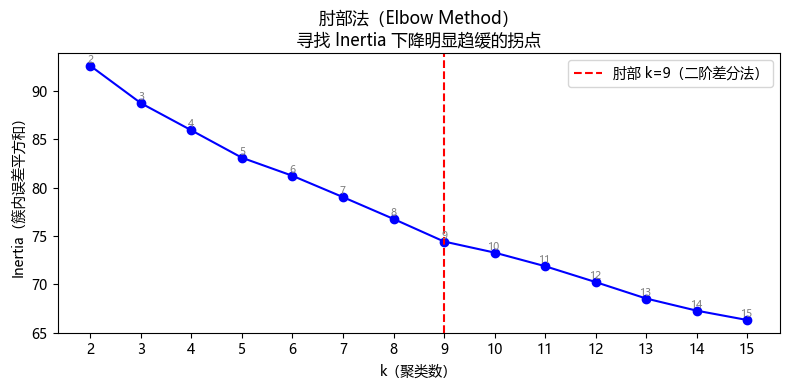


→ 肘部法选定 k = 9


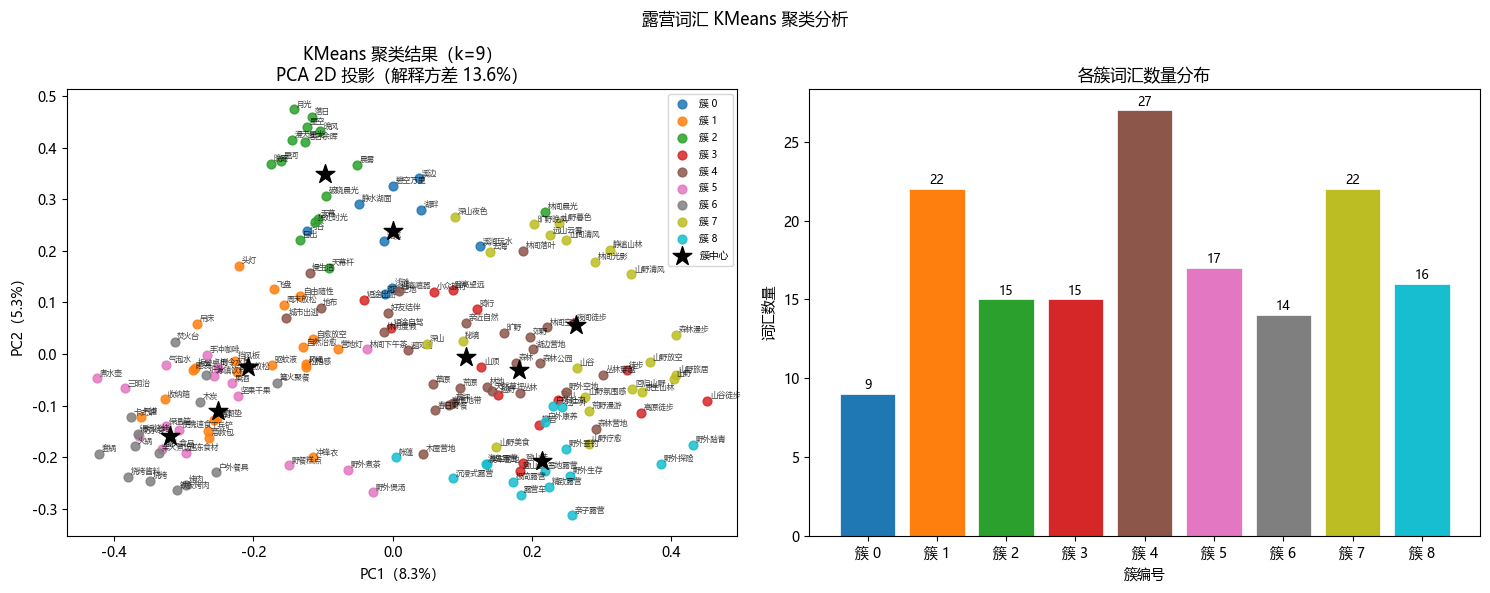


  各簇词汇明细（k=9）

【簇 0】（9 个词）
  河谷、湖畔、溪边、河滩空地、浅滩、溯溪、溪涧玩水、碧空万里
  静水湖面

【簇 1】（22 个词）
  睡袋、防潮垫、收纳箱、营地灯、头灯、气罐、地钉、风绳
  冲锋衣、急救包、工兵铲、驱蚊液、吊床、挡风板、折叠桌椅、飞盘
  松弛感、解压放松、自愈放空、自然治愈、周末放松、自由随性

【簇 2】（15 个词）
  天幕、天幕杆、星空、晚霞、日出、晚风、晨雾、落日
  月光、星河、漫天星光、落日余晖、林间晨光、破晓晨光、独处时光

【簇 3】（15 个词）
  山顶、登山鞋、登山包、徒步、登山、骑行、越野、攀岩
  短途出游、登高望远、山谷徒步、短途自驾、高原徒步、夜间徒步、小众旅行

【簇 4】（27 个词）
  林地、草坪、荒原、草原、森林、旷野、郊野、湖边营地
  森林营地、木屋营地、林间空地、森林公园、野外空地、高原地带、丛林、避风湾
  天然草坪、地布、丛林穿越、春日野餐、林间落叶、慢生活、逃离喧嚣、好友结伴
  亲近自然、城市出逃、休闲度假

【簇 5】（17 个词）
  煮水壶、保温箱、防水袋、野外煮茶、手冲咖啡、冰镇饮料、野餐糕点、三明治
  野外煲汤、速冻食材、便携速食、气泡水、果酒、林间下午茶、罐头食品、坚果干果
  时令水果

【簇 6】（14 个词）
  焚火台、卡式炉、套锅、炉头、木炭、户外餐具、烧烤、烤肉
  火锅、柴火煮饭、烧烤酱料、锡纸烧烤、铁板烤肉、篝火聚餐

【簇 7】（22 个词）
  山野、山谷、秘境、原生山林、深山、荒野漫游、森林漫步、山野旅居
  山野放空、山野美食、云海、山间清风、林间光影、山野暮色、旷野晚风、远山云雾
  深山夜色、山野清风、静谧山林、回归山野、山野氛围感、山野疗愈

【簇 8】（16 个词）
  海岛露营、房车营地、帐篷、露营车、野外垂钓、野外探险、野外生存、野外踏青
  雪地露营、轻户外、精致露营、极简露营、沉浸式露营、亲子露营、户外康养、户外社交


In [2]:

# ── 2.4 KMeans 实战：露营领域词汇聚类 ────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from modelscope import snapshot_download
from sentence_transformers import SentenceTransformer

# ── 词汇列表（露营主题，共 157 个）────────────────────────────
words = [
    # 自然地形
    "山野","河谷","湖畔","溪边","山顶","林地","草坪","荒原","山谷","草原",
    "森林","旷野","郊野","秘境",
    # 营地类型
    "湖边营地","森林营地","海岛露营","房车营地","木屋营地","河滩空地",
    "林间空地","原生山林","森林公园","野外空地","高原地带","深山","丛林",
    "浅滩","避风湾","天然草坪",
    # 露营装备
    "帐篷","天幕","睡袋","防潮垫","露营车","收纳箱","营地灯","头灯",
    "焚火台","卡式炉","气罐","煮水壶","套锅","天幕杆","地钉","风绳",
    "登山鞋","冲锋衣","登山包","急救包","工兵铲","驱蚊液","保温箱",
    "吊床","挡风板","炉头","木炭","防水袋","地布","户外餐具","折叠桌椅",
    # 户外活动
    "徒步","登山","溯溪","骑行","越野","攀岩","飞盘","野外垂钓",
    "丛林穿越","野外探险","短途出游","荒野漫游","登高望远","山谷徒步",
    "森林漫步","短途自驾","山野旅居","野外生存","溪涧玩水","野外踏青",
    "春日野餐","高原徒步","雪地露营","夜间徒步","轻户外","精致露营",
    "极简露营","山野放空",
    # 野外饮食
    "烧烤","烤肉","火锅","野外煮茶","手冲咖啡","冰镇饮料","野餐糕点",
    "三明治","柴火煮饭","野外煲汤","速冻食材","烧烤酱料","便携速食",
    "气泡水","果酒","林间下午茶","山野美食","锡纸烧烤","铁板烤肉",
    "罐头食品","坚果干果","时令水果","篝火聚餐",
    # 自然景象
    "星空","晚霞","日出","云海","晚风","晨雾","落日","月光","星河",
    "山间清风","林间光影","山野暮色","漫天星光","落日余晖","旷野晚风",
    "远山云雾","林间晨光","深山夜色","山野清风","林间落叶","碧空万里",
    "静谧山林","静水湖面","破晓晨光",
    # 心境与生活方式
    "松弛感","慢生活","解压放松","自愈放空","逃离喧嚣","沉浸式露营",
    "独处时光","亲子露营","好友结伴","小众旅行","自然治愈","亲近自然",
    "回归山野","城市出逃","休闲度假","户外康养","山野氛围感","户外社交",
    "周末放松","山野疗愈","自由随性",
]
print(f"词汇总数：{len(words)}")

# ── 从 ModelScope 加载模型 ────────────────────────────────────
print("\n正在加载模型...")
model_dir       = snapshot_download('Jerry0/text2vec-base-chinese')
encoder         = SentenceTransformer(model_dir)
embeddings      = encoder.encode(words, show_progress_bar=True)
embeddings_norm = normalize(embeddings)
print(f"\n向量维度：{embeddings.shape}  →  {embeddings.shape[1]} 维语义向量")

# ── 肘部法确定最优 k ──────────────────────────────────────────
inertias = []
k_range  = range(2, 16)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    km.fit(embeddings_norm)
    inertias.append(km.inertia_)

# 二阶差分定量找肘部：下降量本身下降最快的位置
delta2  = np.diff(np.diff(np.array(inertias)))
elbow_k = list(k_range)[np.argmax(delta2) + 1]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), inertias, 'bo-', ms=6, lw=1.5)
ax.axvline(elbow_k, color='red', linestyle='--', lw=1.5,
           label=f'肘部 k={elbow_k}（二阶差分法）')
for k, v in zip(k_range, inertias):
    ax.text(k, v + 0.3, str(k), ha='center', fontsize=7.5, color='gray')
ax.set_xlabel('k（聚类数）')
ax.set_ylabel('Inertia（簇内误差平方和）')
ax.set_title('肘部法（Elbow Method）\n寻找 Inertia 下降明显趋缓的拐点')
ax.legend()
ax.set_xticks(list(k_range))
plt.tight_layout()
plt.show()

print(f"\n→ 肘部法选定 k = {elbow_k}")

# ── 训练最终 KMeans ───────────────────────────────────────────
optimal_k = elbow_k
km_final  = KMeans(n_clusters=optimal_k, init='k-means++', n_init=30, random_state=42)
labels    = km_final.fit_predict(embeddings_norm)

# ── PCA 降维到 2D 可视化 ──────────────────────────────────────
pca           = PCA(n_components=2, random_state=42)
coords        = pca.fit_transform(embeddings_norm)
var_explained = pca.explained_variance_ratio_.sum()

palette        = matplotlib.colormaps['tab10'].resampled(optimal_k)
cluster_colors = [palette(i) for i in range(optimal_k)]

fig, (ax_scatter, ax_bar) = plt.subplots(1, 2, figsize=(15, 6))

for i in range(optimal_k):
    mask = labels == i
    ax_scatter.scatter(coords[mask, 0], coords[mask, 1],
                       color=cluster_colors[i], s=40, alpha=0.85,
                       label=f'簇 {i}', zorder=3)
    for j in np.where(mask)[0]:
        ax_scatter.annotate(words[j], (coords[j, 0], coords[j, 1]),
                            fontsize=5.5, alpha=0.75,
                            xytext=(2, 2), textcoords='offset points')

centers_2d = pca.transform(km_final.cluster_centers_)
ax_scatter.scatter(centers_2d[:, 0], centers_2d[:, 1],
                   marker='*', s=200, c='black', zorder=5, label='簇中心')
ax_scatter.set_title(f'KMeans 聚类结果（k={optimal_k}）\nPCA 2D 投影（解释方差 {var_explained:.1%}）')
ax_scatter.legend(fontsize=7, loc='upper right')
ax_scatter.set_xlabel(f'PC1（{pca.explained_variance_ratio_[0]:.1%}）')
ax_scatter.set_ylabel(f'PC2（{pca.explained_variance_ratio_[1]:.1%}）')

cluster_sizes = [(labels == i).sum() for i in range(optimal_k)]
bars = ax_bar.bar(range(optimal_k), cluster_sizes,
                  color=cluster_colors, edgecolor='white', linewidth=0.5)
for bar, size in zip(bars, cluster_sizes):
    ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(size), ha='center', fontsize=9)
ax_bar.set_xlabel('簇编号')
ax_bar.set_ylabel('词汇数量')
ax_bar.set_title('各簇词汇数量分布')
ax_bar.set_xticks(range(optimal_k))
ax_bar.set_xticklabels([f'簇 {i}' for i in range(optimal_k)])

plt.suptitle('露营词汇 KMeans 聚类分析', fontsize=12)
plt.tight_layout()
plt.show()

# ── 输出各簇词汇 ──────────────────────────────────────────────
print("\n" + "="*60)
print(f"  各簇词汇明细（k={optimal_k}）")
print("="*60)
for i in range(optimal_k):
    cluster_words = [words[j] for j in range(len(words)) if labels[j] == i]
    print(f"\n【簇 {i}】（{len(cluster_words)} 个词）")
    for row_start in range(0, len(cluster_words), 8):
        print("  " + "、".join(cluster_words[row_start:row_start+8]))


### DBSCAN

基于**密度**：密度足够高的区域形成一个簇，稀疏区域的点被标记为**噪声点（异常点）**。

**两个核心参数**：
- `eps`：邻域半径，定义「足够近」的范围
- `min_samples`：在 eps 半径内至少需要多少邻居，才能成为核心点

**三类点的角色**：

| 点类型 | 判断条件 | 说明 |
|--------|----------|------|
| **核心点** | eps 邻域内邻居数 ≥ min_samples | 密集区域的内部点 |
| **边界点** | 邻居数 < min_samples，但在某核心点邻域内 | 簇的边缘点 |
| **噪声点（-1）** | 不是核心点，也不在任何核心点邻域内 | 离群异常点 |

**K-Means vs DBSCAN 对比**：

| | K-Means | DBSCAN |
|--|---------|--------|
| 需要预设簇数量 | ✓ 必须指定 k | ✗ 自动确定 |
| 簇的形状假设 | 球形 | **任意形状** |
| 噪声/异常点检测 | ✗ | ✓ 自动标记为 -1 |
| 适合场景 | 球形、均匀大小的簇 | 环形、月牙形、不规则形状 |

**参数选择经验**：
- `eps` 过大 → 所有点合并为一个大簇；过小 → 几乎所有点都是噪声
- `min_samples` 通常设为特征维度 × 2，或根据数据密度调整
- 实用技巧：对每个点计算第 k 近邻距离，排序后画折线图，**折线拐点对应合适的 eps**

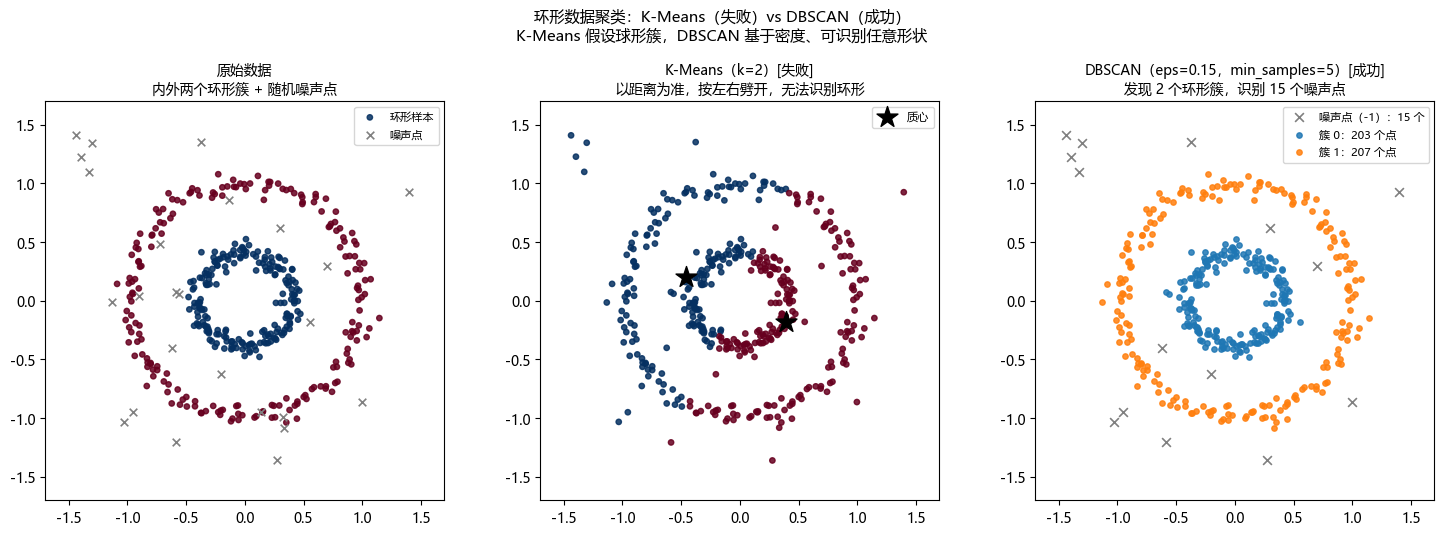

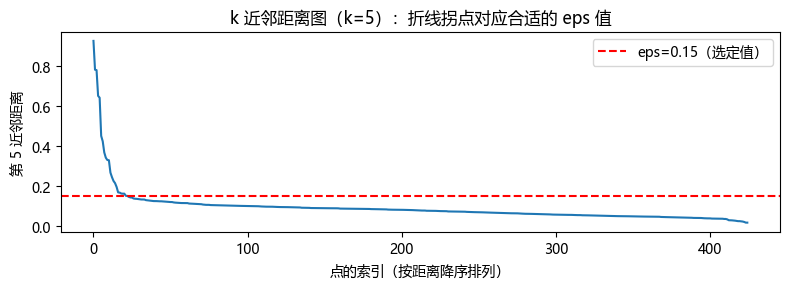

DBSCAN 结果摘要：
  eps=0.15，min_samples=5
  发现簇数量：2
  噪声点数量：15（占 3.5%）
  簇 0：203 个点
  簇 1：207 个点


In [9]:

# ── 2.4 DBSCAN 实战：环形数据聚类对比 ────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.datasets import make_circles
from sklearn.neighbors import NearestNeighbors

np.random.seed(42)

# ── 生成环形数据 + 随机噪声点 ─────────────────────────────────
X_rings, y_rings = make_circles(n_samples=400, noise=0.05, factor=0.4, random_state=42)
noise_pts = np.random.uniform(-1.5, 1.5, size=(25, 2))
X = np.vstack([X_rings, noise_pts])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── 左图：原始数据 ────────────────────────────────────────────
axes[0].scatter(X_rings[:, 0], X_rings[:, 1], c=y_rings, cmap='RdBu',
                s=15, alpha=0.85, label='环形样本')
axes[0].scatter(noise_pts[:, 0], noise_pts[:, 1],
                c='gray', s=30, marker='x', linewidths=1.2, label='噪声点')
axes[0].set_title('原始数据\n内外两个环形簇 + 随机噪声点', fontsize=10)
axes[0].legend(fontsize=8)
axes[0].set_aspect('equal')
axes[0].set_xlim(-1.7, 1.7)
axes[0].set_ylim(-1.7, 1.7)

# ── 中图：K-Means（失败）────────────────────────────────────
km = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=42)
km_labels = km.fit_predict(X)

axes[1].scatter(X[:, 0], X[:, 1], c=km_labels, cmap='RdBu', s=15, alpha=0.85)
axes[1].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
                marker='*', s=250, c='black', zorder=5, label='质心')
axes[1].set_title('K-Means（k=2）[失败]\n以距离为准，按左右劈开，无法识别环形', fontsize=10)
axes[1].legend(fontsize=8)
axes[1].set_aspect('equal')
axes[1].set_xlim(-1.7, 1.7)
axes[1].set_ylim(-1.7, 1.7)

# ── 右图：DBSCAN（成功）──────────────────────────────────────
dbscan = DBSCAN(eps=0.15, min_samples=5)
db_labels = dbscan.fit_predict(X)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = (db_labels == -1).sum()

palette = ['C0', 'C1', 'C2', 'C3']
for label in sorted(set(db_labels)):
    mask = db_labels == label
    if label == -1:
        axes[2].scatter(X[mask, 0], X[mask, 1], c='gray', s=40,
                        marker='x', linewidths=1.2, zorder=4,
                        label=f'噪声点（-1）：{mask.sum()} 个')
    else:
        axes[2].scatter(X[mask, 0], X[mask, 1], c=palette[label % len(palette)],
                        s=15, alpha=0.85, label=f'簇 {label}：{mask.sum()} 个点')

axes[2].set_title(f'DBSCAN（eps=0.15，min_samples=5）[成功]\n发现 {n_clusters} 个环形簇，识别 {n_noise} 个噪声点', fontsize=10)
axes[2].legend(fontsize=8, loc='upper right')
axes[2].set_aspect('equal')
axes[2].set_xlim(-1.7, 1.7)
axes[2].set_ylim(-1.7, 1.7)

plt.suptitle('环形数据聚类：K-Means（失败）vs DBSCAN（成功）\nK-Means 假设球形簇，DBSCAN 基于密度、可识别任意形状',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# ── 附：k 近邻距离图（eps 参数选择技巧）────────────────────
k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X)
distances, _ = nbrs.kneighbors(X)
kth_dist = np.sort(distances[:, -1])[::-1]

fig2, ax2 = plt.subplots(figsize=(8, 3))
ax2.plot(kth_dist, lw=1.5)
ax2.axhline(0.15, color='red', linestyle='--', lw=1.5, label='eps=0.15（选定值）')
ax2.set_xlabel('点的索引（按距离降序排列）')
ax2.set_ylabel(f'第 {k} 近邻距离')
ax2.set_title(f'k 近邻距离图（k={k}）：折线拐点对应合适的 eps 值')
ax2.legend()
plt.tight_layout()
plt.show()

print("DBSCAN 结果摘要：")
print(f"  eps=0.15，min_samples=5")
print(f"  发现簇数量：{n_clusters}")
print(f"  噪声点数量：{n_noise}（占 {n_noise/len(X):.1%}）")
for label in sorted(set(db_labels)):
    if label != -1:
        print(f"  簇 {label}：{(db_labels == label).sum()} 个点")


---

# 第三部分：监督学习

---

## 监督学习概览

监督学习的「分类方式」有两个维度，容易混淆：

### 维度一：按任务类型分（预测目标是什么）

| 任务 | 预测目标 | 典型例子 |
|------|----------|----------|
| **回归（Regression）** | 连续值 | 房价预测、温度预测、销量预测 |
| **分类（Classification）** | 离散标签 | 垃圾邮件判断、猫狗识别、信用评估 |

### 维度二：按模型族分（用什么结构的模型）

| 模型族 | 数学结构 | 能做回归？ | 能做分类？ |
|--------|----------|-----------|-----------|
| **线性模型** | 输出 = 特征的线性组合 | ✅ 线性回归、Ridge、Lasso | ✅ 逻辑回归 |
| **树模型** | 递归二分特征空间 | ✅ 回归树、随机森林回归 | ✅ 分类树、随机森林分类 |
| **支持向量机** | 最大化间隔超平面 | ✅ SVR | ✅ SVC |

> **关键认知**：两个维度互相独立。「线性模型」描述的是模型的数学结构，不是任务类型——线性模型既能做回归（线性回归），也能做分类（逻辑回归）。后续 2.5~2.7 均按**模型族**组织，每节内部再区分回归与分类用法。

## 2.5 线性模型

线性模型假设输出是输入特征的线性组合，是最简单也最常用的一类模型。优点：**可解释性强、训练快、可作为 baseline**。

---

### 用于回归任务

#### 线性回归（Linear Regression）

$$\hat{y} = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b = \mathbf{w}^\top \mathbf{x} + b$$

训练目标：最小化均方误差 $\text{MSE} = \frac{1}{n}\sum(y_i - \hat{y}_i)^2$

**单输出 vs 多输出**：需要同时预测多个目标值时（如温度、湿度、气压），变为**多输出回归**，权重矩阵 $W$ 变为 $m \times d$，$\hat{\mathbf{y}}$ 变为 $m$ 维向量。神经网络的每一个线性层本质上就是这个多输出形式。

#### 扩展到非线性：多项式回归

线性模型本身只能拟合直线。通过**特征工程**可以让它拟合曲线——把原始特征 $x$ 替换为一组新特征：

$$x \;\longrightarrow\; [x,\; x^2,\; x^3,\; \ldots]$$

然后对这组新特征做普通线性回归，得到**多项式回归**：

$$\hat{y} = w_1 x + w_2 x^2 + w_3 x^3 + b$$

**为什么明明有 $x^2$、$x^3$，还说"对参数是线性的"？**

关键在于：**"线性"描述的是 $\hat{y}$ 对权重 $w$ 的关系，不是对 $x$ 的关系。**

换一个视角——把 $x^2$ 和 $x^3$ 看作已经计算好的新特征，重新命名：

$$z_1 = x, \quad z_2 = x^2, \quad z_3 = x^3$$

模型变成：

$$\hat{y} = w_1 z_1 + w_2 z_2 + w_3 z_3 + b$$

这就是标准的线性回归形式——$w$ 都只以一次方出现，没有 $w^2$，没有 $w_1 \cdot w_2$，也没有 $e^w$。

训练时求解的正是这些 $w$，而 $z_1, z_2, z_3$ 是已知的输入数据，不是要优化的对象。所以从**优化角度**看，多项式回归和线性回归完全一样：同样可以用最小二乘法解析求解，同样可以用梯度下降，计算复杂度没有区别。

> **类比**：你去超市买水果，苹果 1 个、橙子 2 个、香蕉 3 个，要算总价。苹果价格、橙子价格、香蕉价格是"参数"（你要求的），个数是"特征"（已知）。不管个数是 1、2 还是 3 的平方，算总价的方式都是线性叠加。

非线性模型是指 $w$ 本身以非线性方式出现，例如 $\hat{y} = e^{w_1 x}$——这时就无法用线性代数方法直接求解了。

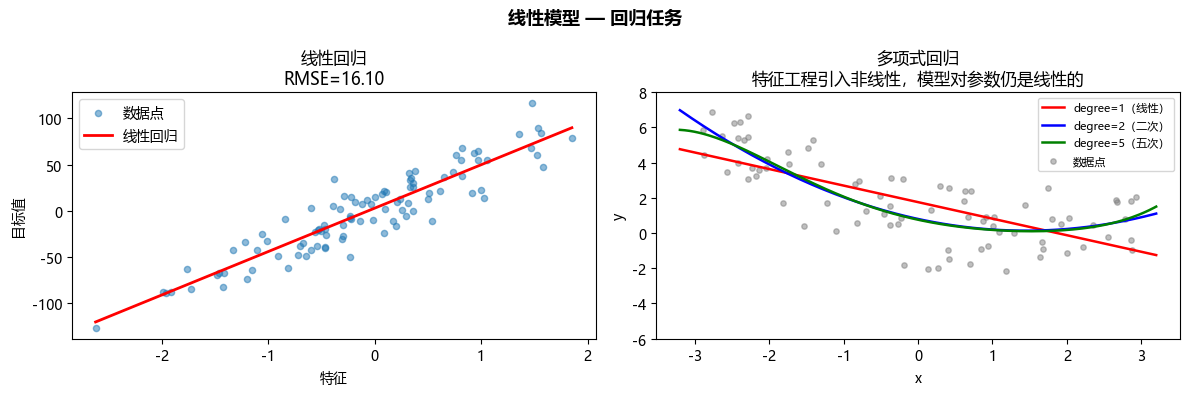

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

np.random.seed(42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('线性模型 — 回归任务', fontsize=13, fontweight='bold')

# ── 图1：线性回归 ─────────────────────────────────────────────
X_reg, y_reg = make_regression(n_samples=100, n_features=1, noise=20)
X_tr, X_te, y_tr, y_te = train_test_split(X_reg, y_reg, test_size=0.2)
lr = LinearRegression().fit(X_tr, y_tr)
rmse = np.sqrt(mean_squared_error(y_te, lr.predict(X_te)))

x_line = np.linspace(X_reg.min(), X_reg.max(), 100).reshape(-1, 1)
axes[0].scatter(X_reg, y_reg, alpha=0.5, s=20, label='数据点')
axes[0].plot(x_line, lr.predict(x_line), 'r-', lw=2, label='线性回归')
axes[0].set_title(f'线性回归\nRMSE={rmse:.2f}')
axes[0].set_xlabel('特征')
axes[0].set_ylabel('目标值')
axes[0].legend()

# ── 图2：多项式回归（特征工程引入非线性） ────────────────────
np.random.seed(0)
X_poly = np.sort(np.random.uniform(-3, 3, 80))
y_poly = 0.5 * X_poly**2 - X_poly + np.random.randn(80) * 1.5
X_p = X_poly.reshape(-1, 1)

x_plot = np.linspace(-3.2, 3.2, 200).reshape(-1, 1)
for deg, color, label in [(1, 'red', 'degree=1（线性）'),
                           (2, 'blue', 'degree=2（二次）'),
                           (5, 'green', 'degree=5（五次）')]:
    model = make_pipeline(PolynomialFeatures(deg), LinearRegression()).fit(X_p, y_poly)
    axes[1].plot(x_plot, model.predict(x_plot), color=color, lw=1.8, label=label)
axes[1].scatter(X_poly, y_poly, s=15, alpha=0.5, color='gray', label='数据点')
axes[1].set_title('多项式回归\n特征工程引入非线性，模型对参数仍是线性的')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].legend(fontsize=8)
axes[1].set_ylim(-6, 8)

plt.tight_layout()
plt.show()


### 用于分类任务

#### 逻辑回归（Logistic Regression）

名字里有"回归"，但它是**分类**模型。在线性输出上套一个 Sigmoid 函数，将结果压缩到 (0, 1) 作为概率：

$$P(y=1|\mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b) = \frac{1}{1+e^{-(\mathbf{w}^\top \mathbf{x} + b)}}$$

训练目标：最小化**交叉熵损失**（等价于最大化对数似然）。

决策边界是特征空间中的一条**线性超平面**（2D 下是直线）。

> 模型输出的是**概率**（连续值），把概率 > 0.5 判为正类是人为加的后处理，不是模型本身。

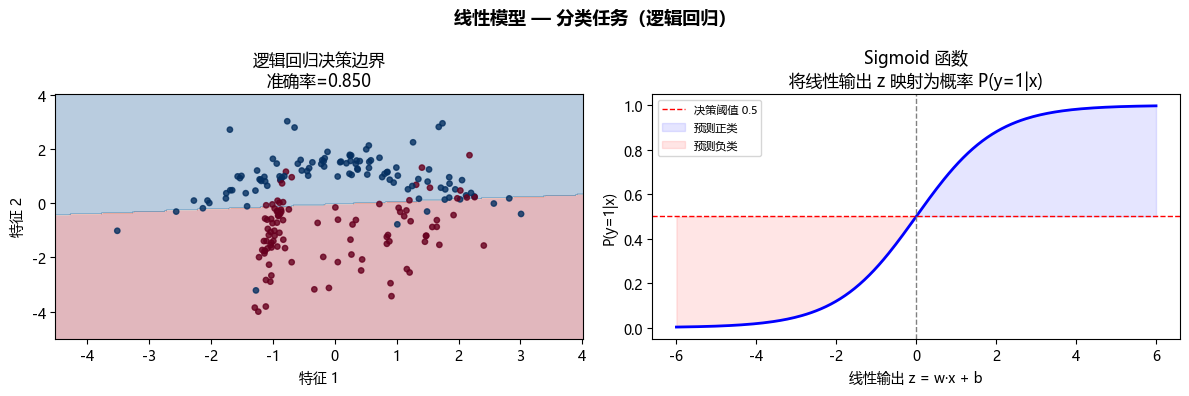

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('线性模型 — 分类任务（逻辑回归）', fontsize=13, fontweight='bold')

# ── 图1：逻辑回归决策边界 ─────────────────────────────────────
X_cls, y_cls = make_classification(n_samples=200, n_features=2, n_redundant=0,
                                   n_informative=2, random_state=1)
X_tr, X_te, y_tr, y_te = train_test_split(X_cls, y_cls, test_size=0.2)
log_reg = LogisticRegression().fit(X_tr, y_tr)
acc = accuracy_score(y_te, log_reg.predict(X_te))

xx, yy = np.meshgrid(np.linspace(X_cls[:, 0].min() - 1, X_cls[:, 0].max() + 1, 200),
                     np.linspace(X_cls[:, 1].min() - 1, X_cls[:, 1].max() + 1, 200))
Z = log_reg.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[0].contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
axes[0].scatter(X_cls[:, 0], X_cls[:, 1], c=y_cls, cmap='RdBu', s=15, alpha=0.8)
axes[0].set_title(f'逻辑回归决策边界\n准确率={acc:.3f}')
axes[0].set_xlabel('特征 1')
axes[0].set_ylabel('特征 2')

# ── 图2：Sigmoid 函数 ─────────────────────────────────────────
z = np.linspace(-6, 6, 200)
sigmoid = 1 / (1 + np.exp(-z))
axes[1].plot(z, sigmoid, 'b-', lw=2)
axes[1].axhline(0.5, color='r', linestyle='--', lw=1, label='决策阈值 0.5')
axes[1].axvline(0, color='gray', linestyle='--', lw=1)
axes[1].fill_between(z, sigmoid, 0.5, where=(sigmoid > 0.5), alpha=0.1, color='blue', label='预测正类')
axes[1].fill_between(z, sigmoid, 0.5, where=(sigmoid < 0.5), alpha=0.1, color='red', label='预测负类')
axes[1].set_title('Sigmoid 函数\n将线性输出 z 映射为概率 P(y=1|x)')
axes[1].set_xlabel('线性输出 z = w·x + b')
axes[1].set_ylabel('P(y=1|x)')
axes[1].legend(fontsize=8)
axes[1].set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()


## 2.6 树模型与集成学习

**决策树**是本节的基础学习器（base learner）。在此之上，**集成学习（Ensemble Learning）** 通过组合多个弱学习器来提升性能——基础学习器理论上可以是任何模型（SVM、逻辑回归等），本节选用决策树，因为它足够直观，且随机森林、XGBoost 等主流集成方法都以决策树为基础。

本节介绍三类模型：
- **单棵决策树**：基础，直观，容易过拟合
- **Bagging 集成（随机森林）**：并行训练多棵树，投票降低方差
- **Boosting 集成（AdaBoost / XGBoost）**：串行训练，逐步纠错

> 随机森林和 XGBoost 的本质是集成学习方法，之所以放在本节，是因为它们的基础学习器都是决策树。

---

### 实战数据集：Breast Cancer Wisconsin

本节使用 sklearn 内置的 **乳腺癌肿瘤诊断数据集** 贯穿所有模型对比。

| 属性 | 说明 |
|------|------|
| **来源** | 威斯康星大学医院，1992 年采集 |
| **规模** | 569 个样本，30 个数值特征 |
| **任务** | 二分类：恶性（Malignant）/ 良性（Benign） |
| **类别比例** | 良性 357（63%）/ 恶性 212（37%），轻度不平衡 |
| **特征内容** | 针对每个细胞核测量 10 种属性（半径、纹理、周长、面积、光滑度等），每种属性提供均值、标准误差、最大值，共 30 维 |

**为什么选这个数据集？**
- sklearn 直接内置，无需下载和预处理
- 30 个特征足够展示特征重要性的差异
- 医疗场景天然强调 **Recall**（召回率）——漏诊恶性肿瘤的代价远高于误诊

---

### 决策树

每次从所有特征中选出**最优的切分特征和切分点**，把当前节点的样本一分为二，递归向下，直到叶节点只剩一种类别（分类）或方差足够小（回归）。

深度越深 → 模型越复杂 → 越容易过拟合。常用 `max_depth`、`min_samples_leaf` 限制树的生长。

#### 主流决策树算法

决策树的核心差异在于**如何选最优分裂特征**，历史上有三种主流算法：

| 算法 | 年份 | 分裂准则 | 特征类型 | 主要特点 |
|------|------|---------|---------|---------|
| **ID3** | 1986 | 信息增益（Information Gain） | 仅离散特征 | 最早的决策树算法，倾向于选高基数特征（取值多的特征信息增益天然偏高） |
| **C4.5** | 1993 | 增益率（Gain Ratio） | 离散 + 连续 | 修正 ID3 的偏差，用增益率归一化；支持连续特征二分、剪枝、缺失值处理 |
| **CART** | 1984 | Gini 不纯度（分类）/ MSE（回归） | 离散 + 连续 | 只生成**二叉树**（每次一分为二）；同时支持分类和回归；sklearn 使用的就是 CART |

**直觉对比**：

- **信息增益（ID3）**：切完之后两侧越"纯"越好，用香农熵衡量纯度。问题是偏爱取值多的特征——极端情况下用"样本ID"分裂每个叶只有1个样本，信息增益最大，但完全没有泛化能力。
- **增益率（C4.5）**：在信息增益上除以特征自身的熵（取值越多自身熵越大），抑制了高基数偏好。
- **Gini 不纯度（CART）**：计算更快（避免对数运算），二叉分裂结构简单稳定，工程实现友好，成为主流。

> sklearn 的 `DecisionTreeClassifier` / `DecisionTreeRegressor` 均使用 **CART** 算法。

  ID3 决策树：信息熵驱动的特征选择全过程
  数据集：Titanic 乘客生存预测（712 个样本）

数据预览（前 5 行）：
pclass sex age_group embarked  survived
   三等舱   男        成人     南安普顿         0
   一等舱   女        成人       瑟堡         1
   三等舱   女        成人     南安普顿         1
   一等舱   女        成人     南安普顿         1
   三等舱   男        成人     南安普顿         0

类别分布：存活=288，遇难=424（共 712 个样本）

────────────────────────────────────────────────────────────────
  【根节点】全部 712 个样本，计算根节点熵
────────────────────────────────────────────────────────────────

  H(S) = -(288/712) × log₂(288/712)  -  (424/712) × log₂(424/712)
       = -(0.4045) × (-1.3058)  -  (0.5955) × (-0.7478)
       = 0.9735 bits

  → 根节点混乱度 = 0.9735 bits
     存活率约 40.4%，生死尚不确定，熵偏高。


  遍历所有特征，找 IG 最大的分裂点：

  ┌─ 特征「pclass」有 3 个取值
  │   pclass=三等舱：355 样本（存活 85，遇难 270）  H=0.7941  权重=0.4986
  │   pclass=一等舱：184 样本（存活 120，遇难 64）  H=0.9321  权重=0.2584
  │   pclass=二等舱：173 样本（存活 83，遇难 90）  H=0.9988  权重=0.2430
  │
  │  H(S|pclass) = 0.8795
  └  IG(pclass) = 0.9735 - 0.8795 = 0.0940

  ┌─ 特征「s

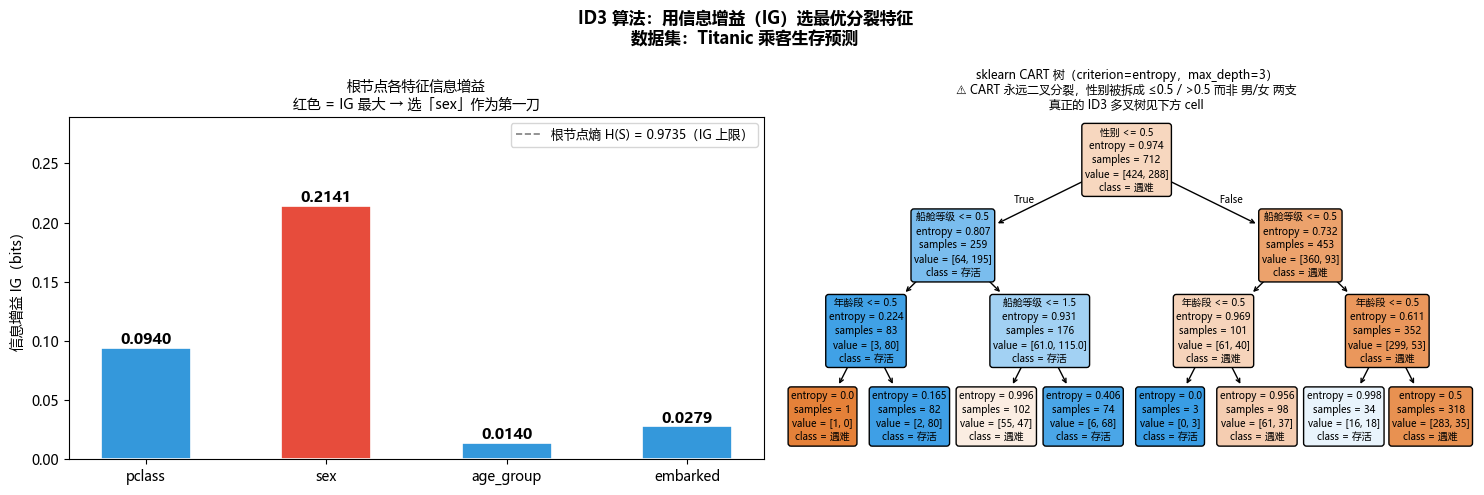


  ID3 算法总结

  ① 信息熵   H(S) = -Σ P(c) × log₂P(c)
  ② 条件熵   H(S|A) = Σᵥ (|Sᵥ|/|S|) × H(Sᵥ)
  ③ 信息增益 IG(A) = H(S) - H(S|A)  → 每层选 IG 最大的特征

  Titanic 数据的直觉验证：
    sex IG 最高（0.2141）→ 性别是最强预测因子（女性存活率远高于男性）
    pclass 次之（0.0940）→ 船舱等级影响逃生资源（一等舱靠近救生艇甲板）
    embarked 最低（0.0279）→ 登船港口与生存关联弱

  ID3 的主要局限：
    1. 偏爱高基数特征（取值多的特征 IG 天然偏高）
    2. 只支持离散特征（连续特征需预先分箱）



In [8]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import OrdinalEncoder

# ══════════════════════════════════════════════════════════════════════
#  ID3 决策树 —— 以 Titanic 生存预测为例
#
#  核心思想：
#    每次分裂时，穷举所有候选特征，计算用该特征分裂后能减少多少"混乱"。
#    "混乱"用【信息熵（Shannon Entropy）】来量化。
#    选信息增益（减少的混乱量）最大的特征作为当前节点的分裂依据，
#    递归向下，直到节点里只剩一种类别（熵=0）为止。
#
#  为什么用 Titanic？
#    - 直接内置于 seaborn，无需下载
#    - 特征含义直观：性别、船舱等级、年龄段、登船港口
#    - 决策树输出的规则完全符合历史直觉（"妇女儿童优先"）
#    - 712 个样本，足以分训练集/测试集
# ══════════════════════════════════════════════════════════════════════

# ── 数据加载与离散化 ──────────────────────────────────────────
# ID3 只支持离散特征，所以把连续的 age 分箱，其余保留原始类别
raw = sns.load_dataset('titanic')
raw = raw[['survived', 'pclass', 'sex', 'age', 'embarked']].dropna()

raw['age_group'] = pd.cut(
    raw['age'],
    bins=[0, 12, 18, 60, 100],
    labels=['儿童', '青少年', '成人', '老年']
)
raw['pclass']   = raw['pclass'].map({1: '一等舱', 2: '二等舱', 3: '三等舱'})
raw['sex']      = raw['sex'].map({'male': '男', 'female': '女'})
raw['embarked'] = raw['embarked'].map({'S': '南安普顿', 'C': '瑟堡', 'Q': '皇后镇'})
df = raw[['pclass', 'sex', 'age_group', 'embarked', 'survived']].copy()
df['survived'] = df['survived'].astype(int)

feature_names = ['pclass', 'sex', 'age_group', 'embarked']

print("=" * 64)
print("  ID3 决策树：信息熵驱动的特征选择全过程")
print("  数据集：Titanic 乘客生存预测（712 个样本）")
print("=" * 64)
print(f"\n数据预览（前 5 行）：")
print(df.head().to_string(index=False))

n_total   = len(df)
n_survive = int(df['survived'].sum())
n_dead    = n_total - n_survive
print(f"\n类别分布：存活={n_survive}，遇难={n_dead}（共 {n_total} 个样本）")


# ══════════════════════════════════════════════════════════════════════
#  工具函数 1：计算信息熵
#
#  H(S) = -Σ P(c) × log₂P(c)
#    H=0 → 全是同一类（纯净）  H=1 → 二分类各 50%（最混乱）
# ══════════════════════════════════════════════════════════════════════
def entropy(labels):
    n = len(labels)
    if n == 0:
        return 0.0
    _, counts = np.unique(labels, return_counts=True)
    p = counts / n
    return float(-np.sum(p * np.log2(p + 1e-15)))


# ══════════════════════════════════════════════════════════════════════
#  工具函数 2：计算信息增益
#
#  IG(A) = H(S) - H(S|A)
#  H(S|A) = Σᵥ (|Sᵥ|/|S|) × H(Sᵥ)   （加权子节点熵）
# ══════════════════════════════════════════════════════════════════════
def info_gain(df_node, feature, target='survived'):
    H_parent = entropy(df_node[target])
    total    = len(df_node)
    H_child  = 0.0
    splits   = {}

    for val in df_node[feature].unique():
        sub = df_node[df_node[feature] == val]
        w   = len(sub) / total
        h   = entropy(sub[target])
        H_child += w * h
        splits[val] = (len(sub), int(sub[target].sum()), h, w)

    ig = H_parent - H_child
    return H_parent, H_child, ig, splits


# ══════════════════════════════════════════════════════════════════════
#  根节点：对 712 个样本计算各特征的信息增益
# ══════════════════════════════════════════════════════════════════════
print("\n" + "─" * 64)
print("  【根节点】全部 712 个样本，计算根节点熵")
print("─" * 64)

H_root = entropy(df['survived'])
p_s    = n_survive / n_total
p_d    = n_dead    / n_total

print(f"\n  H(S) = -({n_survive}/{n_total}) × log₂({n_survive}/{n_total})"
      f"  -  ({n_dead}/{n_total}) × log₂({n_dead}/{n_total})")
print(f"       = -({p_s:.4f}) × ({np.log2(p_s):.4f})"
      f"  -  ({p_d:.4f}) × ({np.log2(p_d):.4f})")
print(f"       = {H_root:.4f} bits")
print(f"\n  → 根节点混乱度 = {H_root:.4f} bits")
print(f"     存活率约 {p_s:.1%}，生死尚不确定，熵偏高。")

print("\n\n  遍历所有特征，找 IG 最大的分裂点：\n")
ig_root = {}
for feat in feature_names:
    H_p, H_c, ig, splits = info_gain(df, feat)
    ig_root[feat] = ig

    print(f"  ┌─ 特征「{feat}」有 {len(splits)} 个取值")
    for val in sorted(splits, key=lambda v: -splits[v][0]):
        n_t, n_p, h, w = splits[val]
        n_n = n_t - n_p
        print(f"  │   {feat}={val}：{n_t} 样本（存活 {n_p}，遇难 {n_n}）"
              f"  H={h:.4f}  权重={w:.4f}")
    print(f"  │")
    print(f"  │  H(S|{feat}) = {H_c:.4f}")
    print(f"  └  IG({feat}) = {H_p:.4f} - {H_c:.4f} = {ig:.4f}\n")

best1 = max(ig_root, key=ig_root.get)
print(f"  ✓ IG 最大：「{best1}」（IG = {ig_root[best1]:.4f}）")
print(f'  → 选「{best1}」作为根节点  （符合历史：泰坦尼克号"女士优先"政策）')


# ── 展开根节点的分支 ──────────────────────────────────────────
print("\n" + "─" * 64)
print(f"  【第二层：展开「{best1}」的分支】")
print("─" * 64)

for val in sorted(df[best1].unique()):
    sub = df[df[best1] == val].drop(columns=[best1]).reset_index(drop=True)
    n_p = int(sub['survived'].sum())
    n_n = len(sub) - n_p
    H_s = entropy(sub['survived'])

    print(f"\n  ▸ {best1}=「{val}」，{len(sub)} 个样本（存活 {n_p}，遇难 {n_n}）  H={H_s:.4f}")

    if H_s < 0.01:
        label = '存活' if n_p > n_n else '遇难'
        print(f"    → 熵 ≈ 0，几乎纯净，叶节点：预测【{label}】")
    else:
        remaining = [f for f in feature_names if f != best1]
        ig_sub = {f: info_gain(sub, f)[2] for f in remaining}
        best2  = max(ig_sub, key=ig_sub.get)
        ig_str = '  '.join(f"IG({f})={v:.4f}" for f, v in ig_sub.items())
        print(f"    → 熵 > 0，继续分裂：{ig_str}")
        print(f"    → 选「{best2}」（IG 最大）继续分裂")


# ══════════════════════════════════════════════════════════════════════
#  可视化
#  左图：根节点各特征 IG 对比
#  右图：sklearn criterion='entropy' 决策树（CART 二叉树，非 ID3 多叉树）
#
#  注意：sklearn 使用 CART 算法，永远做二叉分裂。
#        criterion='entropy' 只改变打分方式（用信息增益选特征），
#        不改变分裂结构——sex 会被拆成 "男 vs 女" 两条路，
#        而非 ID3 的 "每个取值一条路"。
#        下方 c6e5da90 cell 给出纯 Python ID3 真正的多叉树结构。
# ══════════════════════════════════════════════════════════════════════
enc   = OrdinalEncoder()
X_enc = enc.fit_transform(df[feature_names])
y     = df['survived'].values

clf = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
clf.fit(X_enc, y)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 左图：IG 柱状图
feats      = list(ig_root.keys())
ig_vals    = [ig_root[f] for f in feats]
bar_colors = ['#E74C3C' if f == best1 else '#3498DB' for f in feats]

bars = axes[0].bar(feats, ig_vals, color=bar_colors, width=0.5,
                   edgecolor='white', linewidth=1.2)
for bar, v in zip(bars, ig_vals):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                 f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')

axes[0].set_ylim(0, max(ig_vals) * 1.35)
axes[0].set_ylabel('信息增益 IG（bits）', fontsize=10)
axes[0].set_title(f'根节点各特征信息增益\n红色 = IG 最大 → 选「{best1}」作为第一刀', fontsize=10)
axes[0].axhline(H_root, color='gray', lw=1.2, ls='--',
                label=f'根节点熵 H(S) = {H_root:.4f}（IG 上限）')
axes[0].legend(fontsize=9)

# 右图：sklearn 决策树（CART 二叉树结构）
feat_labels = ['船舱等级', '性别', '年龄段', '登船港口']
plot_tree(clf, ax=axes[1],
          feature_names=feat_labels,
          class_names=['遇难', '存活'],
          filled=True, fontsize=7, impurity=True, rounded=True)
axes[1].set_title('sklearn CART 树（criterion=entropy，max_depth=3）\n'
                  '⚠️ CART 永远二叉分裂，性别被拆成 ≤0.5 / >0.5 而非 男/女 两支\n'
                  '真正的 ID3 多叉树见下方 cell',
                  fontsize=8.5)

plt.suptitle('ID3 算法：用信息增益（IG）选最优分裂特征\n数据集：Titanic 乘客生存预测',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "=" * 64)
print("  ID3 算法总结")
print("=" * 64)
print("""
  ① 信息熵   H(S) = -Σ P(c) × log₂P(c)
  ② 条件熵   H(S|A) = Σᵥ (|Sᵥ|/|S|) × H(Sᵥ)
  ③ 信息增益 IG(A) = H(S) - H(S|A)  → 每层选 IG 最大的特征

  Titanic 数据的直觉验证：
    sex IG 最高（0.2141）→ 性别是最强预测因子（女性存活率远高于男性）
    pclass 次之（0.0940）→ 船舱等级影响逃生资源（一等舱靠近救生艇甲板）
    embarked 最低（0.0279）→ 登船港口与生存关联弱

  ID3 的主要局限：
    1. 偏爱高基数特征（取值多的特征 IG 天然偏高）
    2. 只支持离散特征（连续特征需预先分箱）
""")


In [7]:

# ══════════════════════════════════════════════════════════════════════
#  ID3 真正的多叉树 —— 纯 Python 实现，逐步展示建树过程
#
#  上方 sklearn CART 树永远只做二叉分裂：
#    sex（2取值）→ 拆成 性别_encoded ≤ 0.5 / > 0.5
#    pclass（3取值）→ 拆成 pclass_encoded ≤ 1.0 / > 1.0
#
#  真正的 ID3 是多叉树，每个取值对应一个独立子节点：
#    sex（2取值）→ 2 个分支：男 / 女
#    pclass（3取值）→ 3 个分支：一等舱 / 二等舱 / 三等舱
#
#  本 cell 复用上方已定义的：df, feature_names, entropy(), info_gain()
# ══════════════════════════════════════════════════════════════════════

class ID3Node:
    """ID3 树节点：内部节点存分裂特征，叶节点存预测类别"""
    def __init__(self, feature=None, label=None):
        self.feature  = feature
        self.label    = label
        self.children = {}

    def predict(self, sample: dict):
        if self.label is not None:
            return self.label
        child = self.children.get(sample.get(self.feature))
        return child.predict(sample) if child is not None else None


def id3_fit(df, features, target='survived', depth=0, branch='根节点'):
    """
    递归构建 ID3 多叉树，同时打印每步的 IG 计算和特征选择。
    """
    pad    = '  ' * depth
    labels = df[target]
    n      = len(labels)
    n_yes  = int(labels.sum())
    n_no   = n - n_yes
    H      = entropy(labels.values)

    marker = '◆' if depth == 0 else '○'
    print(f"{pad}{marker} 【{branch}】  {n}样本（存活={n_yes}, 遇难={n_no}）  H={H:.4f}")

    # 终止条件①：节点已纯净
    if H < 0.01:
        pred = '存活' if n_yes > n_no else '遇难'
        print(f"{pad}  → 叶节点：H≈0，纯净，预测【{pred}】")
        return ID3Node(label=1 if n_yes > n_no else 0)

    # 终止条件②：无剩余特征
    if not features:
        pred = '存活' if n_yes >= n_no else '遇难'
        print(f"{pad}  → 叶节点：无剩余特征，取多数类【{pred}】")
        return ID3Node(label=1 if n_yes >= n_no else 0)

    # 计算所有候选特征的 IG，选最大的
    ig_map = {f: info_gain(df, f, target)[2] for f in features}
    best   = max(ig_map, key=ig_map.get)

    ig_line = '  '.join(f"IG({f})={v:.4f}" for f, v in ig_map.items())
    vals    = sorted(df[best].unique())
    print(f"{pad}  IG → {ig_line}")
    print(f"{pad}  → 选「{best}」（IG={ig_map[best]:.4f} 最大），"
          f"展开 {len(vals)} 个分支：{vals}")

    node      = ID3Node(feature=best)
    remaining = [f for f in features if f != best]
    for val in vals:
        sub = df[df[best] == val].drop(columns=[best]).reset_index(drop=True)
        node.children[val] = id3_fit(sub, remaining, target, depth + 1,
                                      f"{best}={val}")
    return node


def show_tree(node, pfx='', is_last=True, val_str='根节点', _is_root=True):
    """以 ASCII 树形图打印最终的多叉树结构"""
    conn = '' if _is_root else ('└── ' if is_last else '├── ')

    if node.label is not None:
        pred = '存活' if node.label == 1 else '遇难'
        print(f"{pfx}{conn}[{val_str}]  →  预测【{pred}】")
    else:
        print(f"{pfx}{conn}[{val_str}]  分裂特征：「{node.feature}」")
        kids      = sorted(node.children.items())
        child_pfx = pfx + ('' if _is_root else ('    ' if is_last else '│   '))
        for i, (val, child) in enumerate(kids):
            show_tree(child, child_pfx, i == len(kids) - 1,
                      f"{node.feature}={val}", _is_root=False)


# ══════════════════════════════════════════════════════════════════════
#  建树（在全量 712 个样本上，用于展示结构）
# ══════════════════════════════════════════════════════════════════════
print("=" * 64)
print("  ID3 多叉树：建树全过程（Titanic 712 个样本）")
print("=" * 64)
print()
tree = id3_fit(df.copy(), list(feature_names))

print()
print("=" * 64)
print("  最终树结构（多叉 ASCII 图）")
print("=" * 64)
print()
show_tree(tree)


# ══════════════════════════════════════════════════════════════════════
#  训练集 / 测试集评估
#  以 80/20 分割评估泛化能力，并与 sklearn CART 对比
# ══════════════════════════════════════════════════════════════════════
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OrdinalEncoder

print()
print("=" * 64)
print("  训练集 / 测试集评估（80% 训练，20% 测试）")
print("=" * 64)

df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['survived'])

# ── ID3 手写多叉树 ────────────────────────────────────────────
id3_tree = id3_fit(df_train.copy(), list(feature_names), depth=99, branch='根节点（训练集）')

def predict_all(tree, df_test, feature_names):
    preds = []
    for _, row in df_test.iterrows():
        sample = {f: row[f] for f in feature_names}
        pred   = tree.predict(sample)
        preds.append(pred if pred is not None else 0)
    return preds

# 重定向打印到 /dev/null 以避免刷屏，只保留评估结果
import io, sys
old_stdout = sys.stdout
sys.stdout  = io.StringIO()
id3_tree    = id3_fit(df_train.copy(), list(feature_names))
sys.stdout  = old_stdout

id3_preds = predict_all(id3_tree, df_test, feature_names)
id3_acc   = accuracy_score(df_test['survived'], id3_preds)

# ── sklearn CART（同样用训练集训练）──────────────────────────
enc   = OrdinalEncoder()
X_tr  = enc.fit_transform(df_train[feature_names])
X_te  = enc.transform(df_test[feature_names])
y_tr  = df_train['survived'].values
y_te  = df_test['survived'].values

cart  = DecisionTreeClassifier(criterion='entropy', random_state=42)
cart.fit(X_tr, y_tr)
cart_preds = cart.predict(X_te)
cart_acc   = accuracy_score(y_te, cart_preds)

cart_d3  = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
cart_d3.fit(X_tr, y_tr)
cart_d3_acc = accuracy_score(y_te, cart_d3.predict(X_te))

print(f"\n  测试集（{len(df_test)} 个样本）准确率对比：")
print(f"  {'模型':<30} {'测试准确率':>10}")
print(f"  {'-'*42}")
print(f"  {'ID3 多叉树（纯 Python，不剪枝）':<30} {id3_acc:>10.3f}")
print(f"  {'sklearn CART（不剪枝）':<30} {cart_acc:>10.3f}")
print(f"  {'sklearn CART（max_depth=3）':<30} {cart_d3_acc:>10.3f}")
print(f"""
  观察：
    ID3 和 CART 不剪枝时训练集都是 100%，但测试集通常低于剪枝版本，
    说明两者都过拟合了训练数据。
    max_depth=3 剪枝后泛化能力通常更好——简单的树反而更稳健。
""")


  ID3 多叉树：建树全过程（Titanic 712 个样本）

◆ 【根节点】  712样本（存活=288, 遇难=424）  H=0.9735
  IG → IG(pclass)=0.0940  IG(sex)=0.2141  IG(age_group)=0.0140  IG(embarked)=0.0279
  → 选「sex」（IG=0.2141 最大），展开 2 个分支：['女', '男']
  ○ 【sex=女】  259样本（存活=195, 遇难=64）  H=0.8067
    IG → IG(pclass)=0.2267  IG(age_group)=0.0158  IG(embarked)=0.0329
    → 选「pclass」（IG=0.2267 最大），展开 3 个分支：['一等舱', '三等舱', '二等舱']
    ○ 【pclass=一等舱】  83样本（存活=80, 遇难=3）  H=0.2243
      IG → IG(age_group)=0.0660  IG(embarked)=0.0025
      → 选「age_group」（IG=0.0660 最大），展开 4 个分支：['儿童', '成人', '老年', '青少年']
      ○ 【age_group=儿童】  1样本（存活=0, 遇难=1）  H=-0.0000
        → 叶节点：H≈0，纯净，预测【遇难】
      ○ 【age_group=成人】  71样本（存活=69, 遇难=2）  H=0.1851
        IG → IG(embarked)=0.0006
        → 选「embarked」（IG=0.0006 最大），展开 3 个分支：['南安普顿', '瑟堡', '皇后镇']
        ○ 【embarked=南安普顿】  36样本（存活=35, 遇难=1）  H=0.1831
          → 叶节点：无剩余特征，取多数类【存活】
        ○ 【embarked=瑟堡】  34样本（存活=33, 遇难=1）  H=0.1914
          → 叶节点：无剩余特征，取多数类【存活】
        ○ 【embarked=皇后镇】  1样本（存活=1, 遇难=0）  H=-0.0

### Bagging 集成（随机森林）

单棵决策树容易过拟合——深度无限制时，它会把训练集的每个噪声都"记住"。随机森林的思路是：**训练很多棵互不相同的树，用它们的集体投票代替单棵树的判断**。

两个"随机"的来源：
- **行采样（Bootstrap）**：每棵树只看训练集的一个随机子集（约 63%，有放回抽样）
- **列采样**：每次分裂时只从随机选取的一部分特征中挑最优切分点

两个随机让每棵树都"犯不同的错误"，投票之后错误相互抵消，整体泛化能力显著提升。这种「有放回抽样训练多个模型再集成」的策略叫做 **Bagging（Bootstrap Aggregating）**，随机森林是 Bagging 最经典的实现。

| | 决策树 | 随机森林 |
|--|--------|----------|
| 过拟合风险 | 高（深树记住噪声） | 低（集成平均平滑了噪声） |
| 可解释性 | 强（可打印整棵树） | 弱（几百棵树难以直接查看） |
| 特征重要性 | 支持 | 支持（更稳定） |
| 训练速度 | 快 | 较慢（树多，但可并行） |

- `n_estimators`：树的数量，越多越稳定，但有收益递减，通常 100~500 足够
- 每棵树的预测**并行**计算，可利用多核加速

### Boosting 集成

随机森林是**并行**训练一堆独立的树；Boosting 是**串行**训练，每棵新树专门拟合上一轮的**残差**（预测误差），一轮一轮地把错误修正掉。

```
第1棵树：预测结果，误差 = 真实值 - 预测值
第2棵树：专门学第1棵树的误差
第3棵树：专门学前两棵树加起来之后的剩余误差
……
最终预测 = 所有树的预测值加权求和
```

Boosting 是一大族算法，核心理念相同但机制不同：

#### AdaBoost（1996）

- **纠错方式**：每轮训练后，把**分错的样本权重调高**，下一棵树重点学这些难样本
- 弱学习器通常是深度 = 1 的**树桩（stump）**
- 最终预测 = 各棵树的**加权投票**（准确率高的树权重大）
- **缺点**：对噪声和离群点敏感，难样本权重不断放大可能导致过拟合噪声

#### GBDT / Gradient Boosting（2001）

- **纠错方式**：每棵新树直接拟合**损失函数的负梯度（即残差）**
- 可以优化任意可微的损失函数（MSE、交叉熵等），比 AdaBoost 更通用
- sklearn 的 `GradientBoostingClassifier` 是经典 GBDT 实现
- **缺点**：原版实现较慢，树只能串行构建，大数据集耗时长

#### XGBoost（2016）

- 同样是梯度提升，但做了大量工程优化：
  - 用**二阶泰勒展开**近似损失函数，梯度更新更精确
  - 内置 **L1/L2 正则化**，天然防过拟合
  - 支持**列采样**（借鉴随机森林），增加多样性
  - 树节点分裂**并行化**（虽然树仍串行，但单棵树的节点可并行计算）
  - 自动处理缺失值

#### LightGBM（2017，微软）

- 用**直方图分箱**替代精确搜索分裂点，速度比 XGBoost 快约 10×
- **叶优先生长**（leaf-wise）：每次分裂增益最大的叶，同样深度下精度更高
- 大规模数据集首选

---

**三种 Boosting 变体横向对比**：

| | AdaBoost | GBDT | XGBoost |
|--|---------|------|---------|
| 纠错方式 | 调高错误样本权重 | 拟合残差（一阶梯度） | 拟合残差（二阶梯度）+ 正则化 |
| 弱学习器 | 树桩（depth=1） | 较浅的树 | 较浅的树 |
| 过拟合风险 | 高（噪声敏感） | 中 | 低（内置正则化） |
| 实际使用 | 教学演示 | 理论基础 | 竞赛和生产主流 |

| | 随机森林（Bagging） | Boosting（XGBoost） |
|--|------------------|---------------------|
| 训练方式 | 并行，互相独立 | 串行，后树依赖前树 |
| 精度 | 好 | 通常更好 |
| 过拟合风险 | 低 | 较高，调参更重要 |
| 关键参数 | `n_estimators` | `n_estimators`、`learning_rate`、`max_depth` |

In [ ]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score, roc_curve

# ══════════════════════════════════════════════════════════════════════
#  集成学习对比：单树 vs 随机森林（Bagging）vs Boosting
#  数据集：Titanic 生存预测（连续特征直接使用，无需离散化）
#
#  与上方 ID3 教学 cell 的区别：
#    - 这里保留 age、fare 等连续特征，更贴近真实 ML 使用场景
#    - 集成模型（随机森林、XGBoost）对连续特征天然支持，无需分箱
# ══════════════════════════════════════════════════════════════════════

# ── 数据准备（保留连续特征，简单填充缺失值）─────────────────
raw = sns.load_dataset('titanic')
df_ml = raw[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']].copy()

df_ml['age']      = df_ml['age'].fillna(df_ml['age'].median())
df_ml['embarked'] = df_ml['embarked'].fillna(df_ml['embarked'].mode()[0])
df_ml['sex']      = OrdinalEncoder().fit_transform(df_ml[['sex']])
df_ml['embarked'] = OrdinalEncoder().fit_transform(df_ml[['embarked']])

feature_cols = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
X = df_ml[feature_cols].values
y = df_ml['survived'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("=" * 64)
print("  集成学习对比：Titanic 生存预测")
print("=" * 64)
print(f"  总样本：{len(df_ml)}，训练集：{len(X_train)}，测试集：{len(X_test)}")
print(f"  特征：{feature_cols}")
print(f"  存活率（训练集）：{y_train.mean():.1%}\n")

# ── 定义 4 个模型 ─────────────────────────────────────────────
models = {
    '决策树\n(depth=3，浅树)':    DecisionTreeClassifier(max_depth=3, random_state=42),
    '决策树\n(无限深度，过拟合)': DecisionTreeClassifier(random_state=42),
    '随机森林\n(Bagging)':        RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'AdaBoost\n(Boosting)':       AdaBoostClassifier(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results[name] = {
        '训练准确率':    accuracy_score(y_train, model.predict(X_train)),
        '测试准确率':    accuracy_score(y_test, y_pred),
        'F1':           f1_score(y_test, y_pred),
        'Recall(存活)': recall_score(y_test, y_pred, pos_label=1),
        'ROC-AUC':      roc_auc_score(y_test, y_proba),
        'CV F1':        cross_val_score(model, X, y, cv=5, scoring='f1', n_jobs=-1).mean(),
        'proba':        y_proba,
    }

print(f"{'模型':<22} {'训练准确率':>8} {'测试准确率':>8} {'F1':>6} {'Recall(存活)':>12} {'ROC-AUC':>8} {'CV F1':>7}")
print("-" * 76)
for name, m in results.items():
    print(f"{name.replace(chr(10),' '):<22} {m['训练准确率']:>8.3f} {m['测试准确率']:>8.3f} "
          f"{m['F1']:>6.3f} {m['Recall(存活)']:>12.3f} {m['ROC-AUC']:>8.3f} {m['CV F1']:>7.3f}")

# ── 可视化（4 图）────────────────────────────────────────────
model_names = list(results.keys())
colors = ['#5B9BD5', '#ED7D31', '#70AD47', '#9B59B6']

fig = plt.figure(figsize=(17, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

# 图1：训练 vs 测试准确率（过拟合诊断）
ax1 = fig.add_subplot(gs[0, 0])
x, w = np.arange(len(model_names)), 0.35
ax1.bar(x - w/2, [results[n]['训练准确率'] for n in model_names],
        width=w, label='训练集', color=colors, alpha=0.4, edgecolor='gray')
bars_te = ax1.bar(x + w/2, [results[n]['测试准确率'] for n in model_names],
                  width=w, label='测试集', color=colors, alpha=0.95, edgecolor='gray')
for bar in bars_te:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{bar.get_height():.3f}', ha='center', fontsize=7.5)
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, fontsize=8)
ax1.set_ylim(0.75, 1.05)
ax1.set_ylabel('准确率')
ax1.set_title('训练 vs 测试准确率\n浅色=训练，深色=测试，差距大=过拟合', fontsize=9)
ax1.legend(fontsize=8)
ax1.axhline(1.0, color='gray', lw=0.5, ls='--')

# 图2：ROC 曲线
ax2 = fig.add_subplot(gs[0, 1])
for name, c in zip(model_names, colors):
    fpr, tpr, _ = roc_curve(y_test, results[name]['proba'])
    auc = results[name]['ROC-AUC']
    ax2.plot(fpr, tpr, lw=2, color=c, label=f"{name.replace(chr(10),' ')} (AUC={auc:.3f})")
ax2.plot([0,1],[0,1],'k--',lw=1,label='随机猜测')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC 曲线对比\n曲线越靠左上角、AUC 越大越好', fontsize=9)
ax2.legend(fontsize=7.5, loc='lower right')

# 图3：随机森林特征重要性
ax3 = fig.add_subplot(gs[1, 0])
rf_model      = models['随机森林\n(Bagging)']
importances   = rf_model.feature_importances_
feat_sorted   = sorted(zip(feature_cols, importances), key=lambda x: x[1], reverse=True)
feat_names_s  = [f for f, _ in feat_sorted]
feat_vals_s   = [v for _, v in feat_sorted]
feat_labels_cn = {'pclass':'船舱等级','sex':'性别','age':'年龄',
                  'sibsp':'兄弟配偶数','parch':'父母子女数',
                  'fare':'票价','embarked':'登船港口'}
feat_names_cn = [feat_labels_cn[f] for f in feat_names_s]

bars3 = ax3.barh(feat_names_cn, feat_vals_s, color='#70AD47', alpha=0.85, edgecolor='gray')
for bar, v in zip(bars3, feat_vals_s):
    ax3.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
             f'{v:.3f}', va='center', fontsize=8)
ax3.set_xlabel('特征重要性')
ax3.set_title('随机森林特征重要性\n（各特征平均减少的 Gini 不纯度）', fontsize=9)
ax3.invert_yaxis()

# 图4：5 折 CV F1 箱线图
ax4 = fig.add_subplot(gs[1, 1])
cv_all = {name: cross_val_score(model, X, y, cv=5, scoring='f1', n_jobs=-1)
          for name, model in models.items()}
bp = ax4.boxplot([cv_all[n] for n in model_names], patch_artist=True,
                 widths=0.5, medianprops=dict(color='black', lw=2))
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax4.set_xticks(range(1, len(model_names)+1))
ax4.set_xticklabels(model_names, fontsize=8)
ax4.set_ylabel('F1 Score')
ax4.set_title('5 折交叉验证 F1 分布\n箱体越窄 = 结果越稳定', fontsize=9)
ax4.set_ylim(0.5, 0.95)

plt.suptitle('集成学习对比：单树 vs Bagging（随机森林）vs Boosting（AdaBoost）\n数据集：Titanic 乘客生存预测',
             fontsize=12, fontweight='bold')
plt.show()

# ── 关键观察 ──────────────────────────────────────────────────
print("\n=== 关键观察 ===\n")
dt_d = results['决策树\n(无限深度，过拟合)']
rf   = results['随机森林\n(Bagging)']
ada  = results['AdaBoost\n(Boosting)']
dt3  = results['决策树\n(depth=3，浅树)']

print(f"1. 过拟合：深树训练={dt_d['训练准确率']:.3f} vs 测试={dt_d['测试准确率']:.3f}"
      f"（差距 {dt_d['训练准确率']-dt_d['测试准确率']:.3f}）")
print(f"   浅树 depth=3 反而测试={dt3['测试准确率']:.3f}，说明限制深度能改善泛化")
print(f"2. Bagging：随机森林 ROC-AUC={rf['ROC-AUC']:.3f}，"
      f"集成 100 棵树后比单棵稳定得多")
print(f"3. Boosting：AdaBoost ROC-AUC={ada['ROC-AUC']:.3f}，"
      f"串行纠错策略在此数据集的表现")
print(f"\n4. 特征重要性 Top3（随机森林）：")
for fn, fv in feat_sorted[:3]:
    print(f"   {feat_labels_cn[fn]}（{fn}）= {fv:.3f}")
print(f"   → 票价和年龄是最强信号（与历史一致：头等舱票价高、儿童优先）")


## 2.7 支持向量机（SVM）

SVM 的目标是找到一个**间隔最大化**的超平面来分隔两类数据。

### 关键概念

- **支持向量（Support Vectors）**：距离决策边界最近的那些样本点，超平面位置完全由它们决定
- **间隔（Margin）**：两侧支持向量到决策边界的距离之和，SVM 最大化这个值
- **硬间隔**：要求所有点必须被正确分类（不允许误分类，只适合线性可分数据）
- **软间隔**：允许少量误分类，用参数 `C` 控制容忍程度
  - C 大 → 容忍度低 → 间隔小 → 更容易过拟合
  - C 小 → 容忍度高 → 间隔大 → 更简单的模型

### 核函数（Kernel Trick）

对于线性不可分的数据，通过核函数**隐式地将数据映射到高维空间**，在高维空间中找线性可分的超平面：

| 核函数 | 适用场景 |
|--------|----------|
| `linear` | 数据线性可分或特征维度很高 |
| `rbf`（高斯核） | 最常用，适合非线性问题 |
| `poly` | 多项式边界 |

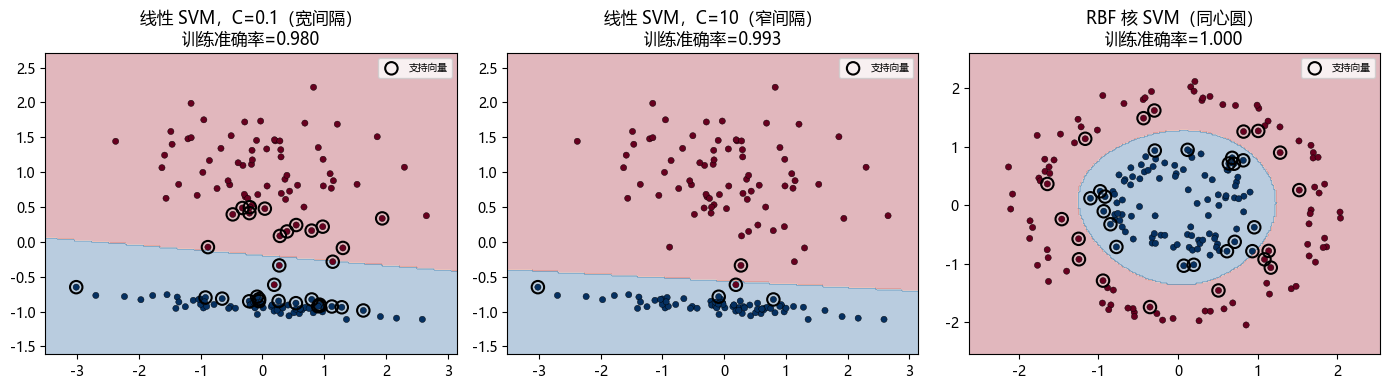

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_circles, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

np.random.seed(42)

def plot_decision_boundary(ax, model, X, y, title):
    h = 0.02
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X[:,0], X[:,1], c=y, cmap='RdBu', s=20, edgecolors='k', linewidths=0.3)
    # 支持向量标记
    if hasattr(model, 'support_vectors_'):
        sv = model.support_vectors_
        ax.scatter(sv[:,0], sv[:,1], s=80, facecolors='none',
                   edgecolors='k', linewidths=1.5, label='支持向量')
    ax.set_title(title)
    ax.legend(fontsize=7)

# ── 数据准备 ──────────────────────────────────────────────────
# 线性可分数据
X_lin, y_lin = make_classification(n_samples=150, n_features=2, n_redundant=0,
                                   n_informative=2, n_clusters_per_class=1, random_state=1)
# 非线性数据（同心圆）
X_cir, y_cir = make_circles(n_samples=200, noise=0.1, factor=0.4, random_state=42)

scaler = StandardScaler()
X_lin_s = scaler.fit_transform(X_lin)
X_cir_s = scaler.fit_transform(X_cir)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 线性 SVM（不同 C 值）
for ax, C, title in zip(axes[:2],
    [0.1, 10],
    ['线性 SVM，C=0.1（宽间隔）', '线性 SVM，C=10（窄间隔）']):
    model = SVC(kernel='linear', C=C).fit(X_lin_s, y_lin)
    acc = accuracy_score(y_lin, model.predict(X_lin_s))
    plot_decision_boundary(ax, model, X_lin_s, y_lin, f'{title}\n训练准确率={acc:.3f}')

# RBF 核 SVM（非线性）
rbf = SVC(kernel='rbf', C=1, gamma='scale').fit(X_cir_s, y_cir)
acc_rbf = accuracy_score(y_cir, rbf.predict(X_cir_s))
plot_decision_boundary(axes[2], rbf, X_cir_s, y_cir,
                       f'RBF 核 SVM（同心圆）\n训练准确率={acc_rbf:.3f}')

plt.tight_layout()
plt.show()

---

# 第四部分：模型评估

---

## 2.8 模型评估

选择正确的评估指标和方法，是 ML 工作中经常被忽视但非常关键的一步。

### 分类指标

混淆矩阵出发：TP（真正例）、FP（假正例）、TN（真负例）、FN（假负例）

| 指标 | 公式 | 关注什么 |
|------|------|----------|
| **Accuracy（准确率）** | (TP+TN)/总数 | 整体正确率，类别不平衡时有误导 |
| **Precision（精确率）** | TP/(TP+FP) | 预测为正的里有多少真的是正 |
| **Recall（召回率）** | TP/(TP+FN) | 所有真正例里被找出来多少 |
| **F1** | 2·P·R/(P+R) | Precision 和 Recall 的调和平均 |
| **ROC-AUC** | — | 不同阈值下综合性能，不受类别不平衡影响 |

**Precision vs Recall 权衡**：提高分类阈值 → Precision↑ Recall↓（漏报少）；降低阈值 → Recall↑ Precision↓（误报多）。

### 回归指标

- **MAE**：平均绝对误差，直观，对异常值不敏感
- **MSE/RMSE**：对大误差更敏感，与损失函数一致
- **R²**：0~1，衡量模型解释了多少方差（1 = 完美拟合）

### 交叉验证（Cross-Validation）

将数据分成 k 折，轮流用 k-1 折训练、1 折验证，取平均评估结果。比单次 train/test 分割更可靠，充分利用数据。

### 偏差-方差权衡

- **高偏差（欠拟合）**：训练集和测试集误差都高 → 模型太简单
- **高方差（过拟合）**：训练集误差低但测试集误差高 → 模型太复杂

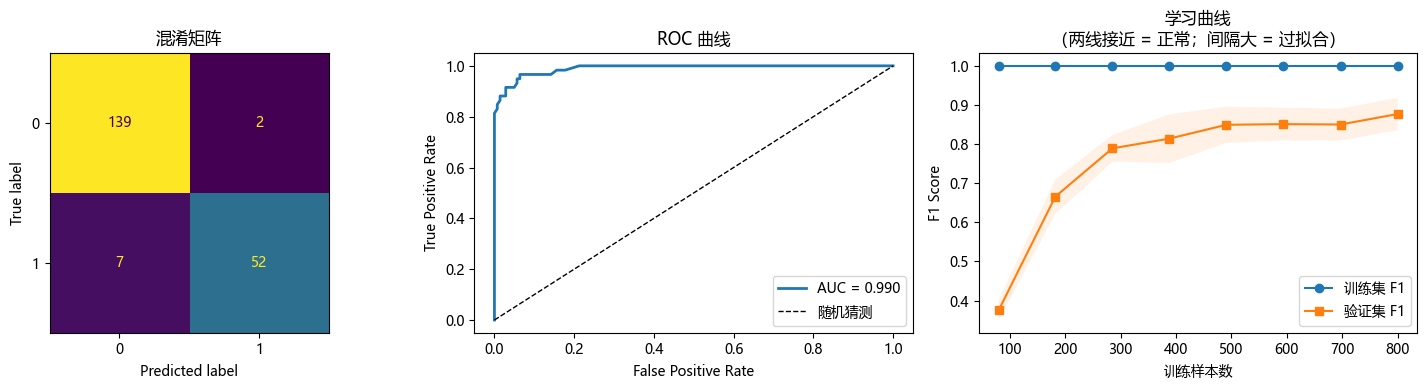

=== 5 折交叉验证 ===
逻辑回归       F1: 0.732 ± 0.032
随机森林       F1: 0.860 ± 0.045

详细报告:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       141
           1       0.96      0.88      0.92        59

    accuracy                           0.95       200
   macro avg       0.96      0.93      0.94       200
weighted avg       0.96      0.95      0.95       200



In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, learning_curve
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, auc, ConfusionMatrixDisplay)
from sklearn.tree import DecisionTreeClassifier

np.random.seed(42)
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10,
                            random_state=42, weights=[0.7, 0.3])  # 轻度不平衡
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 混淆矩阵
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title('混淆矩阵')

# ROC 曲线
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='随机猜测')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC 曲线')
axes[1].legend()

# 学习曲线：诊断偏差/方差
train_sizes, train_scores, val_scores = learning_curve(
    model, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 8),
    scoring='f1', n_jobs=-1
)
train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)
axes[2].plot(train_sizes, train_mean, 'o-', label='训练集 F1')
axes[2].plot(train_sizes, val_mean,   's-', label='验证集 F1')
axes[2].fill_between(train_sizes,
                      train_mean - train_scores.std(axis=1),
                      train_mean + train_scores.std(axis=1), alpha=0.1)
axes[2].fill_between(train_sizes,
                      val_mean - val_scores.std(axis=1),
                      val_mean + val_scores.std(axis=1), alpha=0.1)
axes[2].set_xlabel('训练样本数')
axes[2].set_ylabel('F1 Score')
axes[2].set_title('学习曲线\n（两线接近 = 正常；间隔大 = 过拟合）')
axes[2].legend()

plt.tight_layout()
plt.show()

# 交叉验证
print('=== 5 折交叉验证 ===')
for name, clf in [('逻辑回归', LogisticRegression(max_iter=1000)),
                  ('随机森林', RandomForestClassifier(n_estimators=50, random_state=42))]:
    scores = cross_val_score(clf, X, y, cv=5, scoring='f1')
    print(f'{name:<10} F1: {scores.mean():.3f} ± {scores.std():.3f}')

print(f'\n详细报告:\n{classification_report(y_test, y_pred)}')